# Memes to Markets: WallStreetbets Reddit NLP

## 1. Environment Setup and Data Preparation

The first stage prepares a consistent analytical dataset for the subsequent NLP tasks. Reddit data frequently contains missing post bodies, deleted content, duplicated submissions, URLs, user references, subreddit references, emojis, stock symbols, and community-specific expressions.

For this analysis, the post title and body are combined into one field. This allows short title-only posts and longer due-diligence posts to be processed through the same pipeline. The original text is retained alongside a cleaned version so that model outputs can always be inspected against the unmodified post.

The cleaning process is intentionally conservative. Symbols such as dollar signs, percentages, emojis, and uppercase ticker symbols may contain useful financial information and should not be removed indiscriminately.


In [1]:
# Core libraries
import os
import re
import gc
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

RANDOM_STATE = 42

In [2]:
# Optional Kaggle installation cell.
# Uncomment packages that are not already available in the environment.

# !pip install -q transformers accelerate sentence-transformers
!pip install -q bertopic umap-learn hdbscan
!pip install -q faiss-cpu
# !pip install -q nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 79.3 MB/s eta 0:00:00


Load the data.

In [3]:
DATA_PATH = "/kaggle/input/datasets/gpreda/reddit-wallstreetsbets-posts/reddit_wsb.csv"

if "df" not in globals():
    df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (53187, 8)


,title,score,id,url,comms_num,created,body,timestamp
0,"It's not about the money, it's about sending a message. 🚀💎🙌",55,l6ulcx,https://v.redd.it/6j75regs72e61,6,1.611863e+09,NaN,2021-01-28 21:37:41
1,Math Professor Scott Steiner says the numbers spell DISASTER for Gamestop shorts,110,l6uibd,https://v.redd.it/ah50lyny62e61,23,1.611862e+09,NaN,2021-01-28 21:32:10
2,Exit the system,0,l6uhhn,https://www.reddit.com/r/wallstreetbets/comments/l6uhhn/exit_the_system/,47,1.611862e+09,The CEO of NASDAQ pushed to halt trading “to give investors a chance to recalibrate their positions”.\n\n[https://mobile.twitter.com/Mediaite/status/1354504710695362563](https://mobile.twitter.com/Mediaite/status/1354504710695362563)\n\nNow SEC i...,2021-01-28 21:30:35
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETARDED THAN ME PLEASE INTERPRET?,29,l6ugk6,https://sec.report/Document/0001193125-21-019848/,74,1.611862e+09,NaN,2021-01-28 21:28:57
4,"Not to distract from GME, just thought our AMC brothers should be aware of this",71,l6ufgy,https://i.redd.it/4h2sukb662e61.jpg,156,1.611862e+09,NaN,2021-01-28 21:26:56


In [4]:
def find_first_existing_column(dataframe, candidates):
    """
    Return the first column from candidates that exists in dataframe.
    """
    return next(
        (column for column in candidates if column in dataframe.columns),
        None
    )


title_col = find_first_existing_column(
    df,
    ["title", "post_title", "headline"]
)

body_col = find_first_existing_column(
    df,
    ["body", "selftext", "text", "content"]
)

date_col = find_first_existing_column(
    df,
    ["timestamp", "created", "created_utc", "date", "datetime"]
)

score_col = find_first_existing_column(
    df,
    ["score", "ups", "upvotes"]
)

comments_col = find_first_existing_column(
    df,
    ["comms_num", "num_comments", "comments"]
)

flair_col = find_first_existing_column(
    df,
    ["flair", "link_flair_text", "category"]
)

print("Detected columns")
print("----------------")
print("Title:", title_col)
print("Body:", body_col)
print("Date:", date_col)
print("Score:", score_col)
print("Comments:", comments_col)
print("Flair:", flair_col)

Detected columns
----------------
Title: title
Body: body
Date: timestamp
Score: score
Comments: comms_num
Flair: None


In [5]:
if title_col is None:
    raise ValueError("A title column could not be identified.")

title_text = df[title_col].fillna("").astype(str)

if body_col is not None:
    body_text = df[body_col].fillna("").astype(str)
else:
    body_text = pd.Series("", index=df.index)

df["full_text"] = (
    title_text.str.strip()
    + ". "
    + body_text.str.strip()
).str.strip(" .")

df["title_length"] = title_text.str.len()
df["body_length"] = body_text.str.len()
df["full_text_length"] = df["full_text"].str.len()
df["word_count"] = df["full_text"].str.split().str.len()

display(
    df[
        [
            title_col,
            "full_text",
            "full_text_length",
            "word_count"
        ]
    ].head()
)

,title,full_text,full_text_length,word_count
0,"It's not about the money, it's about sending a message. 🚀💎🙌","It's not about the money, it's about sending a message. 🚀💎🙌",59,11
1,Math Professor Scott Steiner says the numbers spell DISASTER for Gamestop shorts,Math Professor Scott Steiner says the numbers spell DISASTER for Gamestop shorts,80,12
2,Exit the system,Exit the system. The CEO of NASDAQ pushed to halt trading “to give investors a chance to recalibrate their positions”.\n\n[https://mobile.twitter.com/Mediaite/status/1354504710695362563](https://mobile.twitter.com/Mediaite/status/1354504710695362...,1335,229
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETARDED THAN ME PLEASE INTERPRET?,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETARDED THAN ME PLEASE INTERPRET?,75,13
4,"Not to distract from GME, just thought our AMC brothers should be aware of this","Not to distract from GME, just thought our AMC brothers should be aware of this",79,15


### Initial Data-Quality Audit

Before applying NLP models, it is important to understand the quality and completeness of the corpus. Missing values, duplicated posts, extremely short messages, and deleted Reddit content can affect topic modelling and classification results.

In [6]:
quality_summary = pd.Series({
    "number_of_rows": len(df),
    "number_of_columns": df.shape[1],
    "missing_title_percentage": title_text.eq("").mean() * 100,
    "missing_body_percentage": body_text.eq("").mean() * 100,
    "empty_full_text_percentage": df["full_text"].eq("").mean() * 100,
    "duplicate_full_text_percentage": (
        df["full_text"].duplicated().mean() * 100
    ),
    "median_character_length": df["full_text_length"].median(),
    "median_word_count": df["word_count"].median(),
    "posts_under_10_words_percentage": (
        df["word_count"].lt(10).mean() * 100
    )
}).round(2)

display(
    quality_summary.rename("value").to_frame()
)

,value
number_of_rows,53187.00
number_of_columns,13.00
missing_title_percentage,0.00
missing_body_percentage,53.49
empty_full_text_percentage,0.00
duplicate_full_text_percentage,1.08
median_character_length,101.00
median_word_count,18.00
posts_under_10_words_percentage,28.82


In [7]:
# Examine duplicated and very short posts.

duplicate_examples = df[
    df["full_text"].duplicated(keep=False)
].sort_values("full_text")

short_examples = df[
    df["word_count"].between(1, 5)
][[title_col, "full_text", "word_count"]]

print("Duplicate examples")
display(duplicate_examples[[title_col, "full_text"]].head(10))

print("Very short examples")
display(short_examples.head(10))

Duplicate examples


,title,full_text
37233,$AMC,$AMC
34806,$AMC,$AMC
8535,$BB and $NOK to the FUCKING MOON,$BB and $NOK to the FUCKING MOON
3845,$BB and $NOK to the FUCKING MOON,$BB and $NOK to the FUCKING MOON
21738,"$FUBO DD - Connecting the dots, this thing is going to be a MONSTER.","$FUBO DD - Connecting the dots, this thing is going to be a MONSTER.. From u/heardme\n\nPretty sure most of you know $FUBO has been shorted like crazy since the news of their Victory acquisition. It shot up 33% with the news and has since lost mo..."
15360,"$FUBO DD - Connecting the dots, this thing is going to be a MONSTER.","$FUBO DD - Connecting the dots, this thing is going to be a MONSTER.. From u/heardme\n\nPretty sure most of you know $FUBO has been shorted like crazy since the news of their Victory acquisition. It shot up 33% with the news and has since lost mo..."
30220,$GME,$GME
49,$GME,$GME
50165,$TIGR YOLO,$TIGR YOLO
46318,$TIGR YOLO,$TIGR YOLO


Very short examples


,title,full_text,word_count
5,WE BREAKING THROUGH,WE BREAKING THROUGH,3
14,I Love You Retards!!!!,I Love You Retards!!!!,4
41,wsb_churchill_speech.mp69,wsb_churchill_speech.mp69,1
45,THE DARK STOCK RISES.... 🚀🦇🚀,THE DARK STOCK RISES.... 🚀🦇🚀,5
49,$GME,$GME,1
50,Gordan Ramsay becomes a MOD,Gordan Ramsay becomes a MOD,5
63,SEC 'monitoring' short-squeeze volatility,SEC 'monitoring' short-squeeze volatility,4
68,PLTR 🚀 thank you everyone!!!,PLTR 🚀 thank you everyone!!!,5
85,Tell Melvin who we are,Tell Melvin who we are,5
93,JACKED TO THE TITS!!! #pickmeupPLS,JACKED TO THE TITS!!! #pickmeupPLS,5


### WallStreetBets-Aware Text Normalisation

The language used by the WallStreetBets community differs substantially from formal financial reporting. Expressions such as “diamond hands,” “paper hands,” “tendies,” “stonks,” and “MOASS” may communicate stance or investment intent.

The following function normalises some common expressions while preserving the original wording in `full_text`. Stock cashtags are converted into a structured form such as `TICKER_GME`, making them easier for later vectorisation models to recognise.


In [8]:
WSB_NORMALISATION = {
    r"\bstonks?\b": "stocks",
    r"\btendies\b": "profits",
    r"\bdiamond hands\b": "strong hold",
    r"\bpaper hands\b": "early sell",
    r"\bbagholder\b": "loss holding investor",
    r"\bbagholding\b": "holding a losing position",
    r"\bmoass\b": "mother of all short squeezes",
    r"\bdd\b": "due diligence",
    r"\bapes?\b": "retail investors",
    r"\bto the moon\b": "strong price increase",
    r"\bmoon(?:ing)?\b": "price increase",
    r"\bhodl\b": "hold",
    r"\byolo\b": "high risk investment",
}


def clean_wsb_text(text):
    """
    Clean Reddit text while preserving financially meaningful information.
    """
    if not isinstance(text, str):
        return ""

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text
    )

    text = re.sub(
        r"(?<!\w)/?u/[A-Za-z0-9_-]+",
        " USER ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"(?<!\w)/?r/[A-Za-z0-9_-]+",
        " SUBREDDIT ",
        text,
        flags=re.IGNORECASE
    )

    # Preserve explicit cashtags.
    text = re.sub(
        r"\$([A-Za-z]{1,5})\b",
        lambda match: f" TICKER_{match.group(1).upper()} ",
        text
    )

    for pattern, replacement in WSB_NORMALISATION.items():
        text = re.sub(
            pattern,
            replacement,
            text,
            flags=re.IGNORECASE
        )

    # Normalise whitespace without deleting punctuation or emojis.
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["clean_text"] = df["full_text"].map(clean_wsb_text)

display(
    df[
        [
            "full_text",
            "clean_text"
        ]
    ].sample(
        min(10, len(df)),
        random_state=RANDOM_STATE
    )
)

,full_text,clean_text
42975,WSB Rules - Please Read Before Posting. # Welcome to WSB!\n\n\---\n\nAdditional reading: \n\n* [What in the world is WallStreetBets?](https://www.reddit.com/r/wallstreetbets/comments/l8694g/what_in_the_world_is_wallstreetbets/)\n* [Basic Guide to...,WSB Rules - Please Read Before Posting. # Welcome to WSB! \--- Additional reading: * [What in the world is WallStreetBets?]( URL * [Basic Guide to WSB Culture and Lingo]( URL \--- Posts on SUBREDDIT are \*highly moderated\* compared to other subr...
4305,Trading 212 wont give this retard an account :(. Says 'try later' been like that all day. They obvs dont want any more UK rita retards :(,Trading 212 wont give this retard an account :(. Says 'try later' been like that all day. They obvs dont want any more UK rita retards :(
4813,They're saying we throttled but we're higher avg than yesterday?? Makes no sense GME 🚀🚀,They're saying we throttled but we're higher avg than yesterday?? Makes no sense GME 🚀🚀
9281,Vy Global Growth (VYGG): Low-risk investment in what could turn out to be Reddit (The Company)!!!. Hey All\n\nThis is my first post here. Been a regular over at the sub SPACs. You guys should definitely come over. Some good DD on SPACs which end ...,Vy Global Growth (VYGG): Low-risk investment in what could turn out to be Reddit (The Company)!!!. Hey All This is my first post here. Been a regular over at the sub SPACs. You guys should definitely come over. Some good due diligence on SPACs wh...
23686,Weed bet I'm holding for the next few months. $ACB has been a dog but is poised for a comeback. Waiting for golden cross to moon,Weed bet I'm holding for the next few months. TICKER_ACB has been a dog but is poised for a comeback. Waiting for golden cross to price increase
43661,Fuvk you all,Fuvk you all
12301,CASHAPP JUSR LET ME BUY THE FUCKING AMC DIP ITS THE ONLY ONE LEFT BUY LIKE YOUR LIFE DEPENDS ON IT. THIS IS NOT A FUCKING DRILL RETARDS BUY LIKE YOUR LIFE DEPENDS ON IT GO GO GO,CASHAPP JUSR LET ME BUY THE FUCKING AMC DIP ITS THE ONLY ONE LEFT BUY LIKE YOUR LIFE DEPENDS ON IT. THIS IS NOT A FUCKING DRILL RETARDS BUY LIKE YOUR LIFE DEPENDS ON IT GO GO GO
44879,Elon Musk Says Autopilot Wasn't Enabled In Texas Tesla Crash,Elon Musk Says Autopilot Wasn't Enabled In Texas Tesla Crash
22274,💎💎💎,💎💎💎
3419,"couldn't buy on my ROBINHOOD account, so purchased in my vanguard retirement account!!","couldn't buy on my ROBINHOOD account, so purchased in my vanguard retirement account!!"


In [9]:
# Remove rows that contain no usable textual information.

analysis_df = (
    df.loc[df["clean_text"].str.len() > 0]
      .drop_duplicates(subset="clean_text")
      .copy()
      .reset_index(drop=True)
)

print("Original number of posts:", len(df))
print("Usable unique posts:", len(analysis_df))

Original number of posts: 53187
Usable unique posts: 52582


## 2. Temporal Processing

Time is essential for analysing online financial communities because ticker attention, sentiment, and topics can change rapidly. A daily time variable is therefore created before applying the NLP models.

The code handles both Unix timestamps and conventional date strings.

In [10]:
def parse_reddit_datetime(series):
    """
    Parse Unix timestamps or standard datetime strings.
    """
    numeric_values = pd.to_numeric(series, errors="coerce")

    numeric_ratio = numeric_values.notna().mean()

    if numeric_ratio > 0.8:
        non_null = numeric_values.dropna()

        # Millisecond timestamps are generally much larger.
        unit = "ms" if non_null.median() > 10**11 else "s"

        parsed = pd.to_datetime(
            numeric_values,
            unit=unit,
            errors="coerce",
            utc=True
        )
    else:
        parsed = pd.to_datetime(
            series,
            errors="coerce",
            utc=True
        )

    return parsed


if date_col is not None:
    analysis_df["post_datetime"] = parse_reddit_datetime(
        analysis_df[date_col]
    )

    analysis_df["post_date"] = (
        analysis_df["post_datetime"].dt.floor("D")
    )

    analysis_df["post_hour"] = (
        analysis_df["post_datetime"].dt.hour
    )

    analysis_df["day_of_week"] = (
        analysis_df["post_datetime"].dt.day_name()
    )

    print(
        "Date range:",
        analysis_df["post_datetime"].min(),
        "to",
        analysis_df["post_datetime"].max()
    )
else:
    print("No date column was detected.")

Date range: 2020-09-29 03:46:56+00:00 to 2021-08-16 09:26:20+00:00


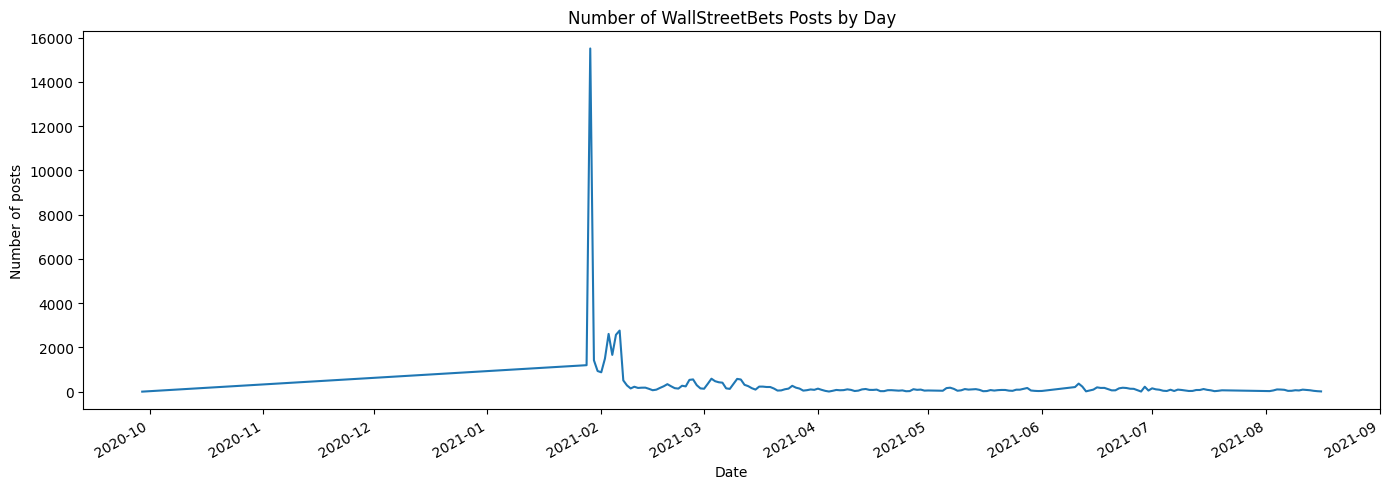

In [11]:
if "post_date" in analysis_df.columns:
    daily_posts = (
        analysis_df.groupby("post_date")
        .size()
        .rename("number_of_posts")
    )

    plt.figure(figsize=(14, 5))
    daily_posts.plot()
    plt.title("Number of WallStreetBets Posts by Day")
    plt.xlabel("Date")
    plt.ylabel("Number of posts")
    plt.tight_layout()
    plt.show()

## 3. Stock-Ticker Extraction

A fundamental NLP task in financial social-media analysis is recognising the companies or exchange-traded funds discussed in each post.

A simple regular expression that selects every uppercase word would generate many false positives. Terms such as `DD`, `CEO`, `IPO`, `USA`, `YOLO`, and `WSB` resemble ticker symbols but do not necessarily identify securities.

The extraction procedure therefore combines:

1. explicit cashtags such as `$GME`;
2. uppercase ticker-like tokens;
3. a list of known tradable symbols;
4. an exclusion list for common ambiguous abbreviations.

For a production analysis, `known_tickers` should be built from a current NASDAQ, NYSE, and ETF symbol list.


In [12]:
# A compact starter universe for demonstration.
# Replace or expand this set using an official exchange-symbol file.

known_tickers = {
    "AAPL", "ABBV", "ABNB", "AMD", "AMZN", "AMC",
    "BA", "BABA", "BB", "BBBY", "BYND",
    "COIN", "CRSR", "CVNA",
    "DIS", "DKNG",
    "FB", "F", "FUBO",
    "GME", "GOOG", "GOOGL",
    "INTC",
    "LCID",
    "META", "MSFT",
    "NFLX", "NIO", "NOK", "NVDA",
    "OPEN",
    "PATH", "PLTR", "PYPL",
    "QQQ",
    "RIVN", "ROKU",
    "SNDL", "SOFI", "SPCE", "SPY",
    "TLRY", "TSLA",
    "UBER",
    "WISH",
    "X", "XOM"
}

ambiguous_tokens = {
    "A", "I", "AI", "ALL", "ARE", "ATH", "ATM",
    "BE", "CEO", "CFO", "DD", "EDIT", "ETF",
    "FOR", "GDP", "IMO", "IPO", "ITM", "LOL",
    "NEW", "NOW", "NYSE", "OTM", "SEC", "THE",
    "UK", "US", "USA", "WSB", "YOLO"
}

In [13]:
cashtag_pattern = re.compile(
    r"(?<!\w)\$([A-Za-z]{1,5})(?!\w)"
)

uppercase_pattern = re.compile(
    r"(?<![A-Za-z0-9])([A-Z]{1,5})(?![A-Za-z0-9])"
)


def extract_tickers(text, valid_tickers=None):
    """
    Extract explicit cashtags and valid uppercase ticker mentions.
    """
    if not isinstance(text, str):
        return []

    valid_tickers = valid_tickers or set()

    cashtags = {
        match.upper()
        for match in cashtag_pattern.findall(text)
    }

    uppercase_candidates = {
        match.upper()
        for match in uppercase_pattern.findall(text)
    }

    uppercase_tickers = {
        token
        for token in uppercase_candidates
        if token in valid_tickers
        and token not in ambiguous_tokens
    }

    extracted = sorted(
        (cashtags | uppercase_tickers)
        - ambiguous_tokens
    )

    return extracted


analysis_df["tickers"] = analysis_df["full_text"].map(
    lambda text: extract_tickers(
        text,
        valid_tickers=known_tickers
    )
)

analysis_df["ticker_count"] = (
    analysis_df["tickers"].str.len()
)

display(
    analysis_df[
        [
            "full_text",
            "tickers",
            "ticker_count"
        ]
    ].sample(
        min(15, len(analysis_df)),
        random_state=RANDOM_STATE
    )
)

,full_text,tickers,ticker_count
11200,OH SHIT ITS A WAR BOIS,[],0
34471,Remember that time you bought 12k riot and sold for pennies? 🤢🧻🤚,[],0
7277,HOLD THE LINE!. If we sell they win. Buy $AMC!,[AMC],1
49291,"Daily option statistics for AMC, CLNE, BB, WISH, GME, WKHS, CLOV, PLTR, CLF, and others.. Hey guys,\n\nHere is the daily option statistics for the most talked about stocks on WSB.\n\nAcross the board we are having green on the big names. $AMC sho...","[AMC, AMD, BB, DKNG, GME, NVDA, PLTR, WISH]",8
35291,The Squeeze CASE for AMC just doesn't exist .. fundamental and technical analysis. **1.\tNo there is no real short squeeze possible**\n\nWhat you have seen is short term momentum trading – and this has very very short legs as seen before and as i...,[AMC],1
15359,We are at FUCKING WAR!. These big hedge funds and trading platforms think that 5 million autists can't beat them? We are in for the long haul! Fuck all these guys on the top trying to steal money from under our noses. We now have the backing from...,[GME],1
21980,You degenerates are contagious - Fuck it. Buy that dip! 💎✋💎✋,[],0
31782,"Suggestion / Request for this subreddit. Given the large daily volume of posts, especially when there is one or more highly active stocks, would it be possible to have a sticky post that summarizes the different tickers that have been discussed? ...",[],0
32485,"Some important advice for my fellow Canadian investors.. Maybe it was just me who didn't know this but put your investments/stocks into a RRSP or TFSA account immediately if you haven't already. If you currently just use a margin account, 50% o...",[],0
31199,"At this point, yall are pathetic.. Party's over. Most people still here are bag holders who have convinced each other that 'sticking it to the man' was worth losing 6k of their 45k net worth.\n\nOr worse, they think it's still ""going to the moon""...",[GME],1


### Most Frequently Mentioned Tickers

Each ticker is counted once per post to prevent repeated mentions in a single submission from dominating the results.


In [14]:
ticker_frequency = Counter(
    ticker
    for ticker_list in analysis_df["tickers"]
    for ticker in set(ticker_list)
)

ticker_frequency_df = pd.DataFrame(
    ticker_frequency.most_common(),
    columns=["ticker", "number_of_posts"]
)

display(ticker_frequency_df.head(25))

,ticker,number_of_posts
0,GME,12946
1,AMC,4936
2,BB,2084
3,NOK,1546
4,PLTR,794
5,TSLA,577
6,SPY,423
7,SNDL,375
8,F,371
9,AMD,366


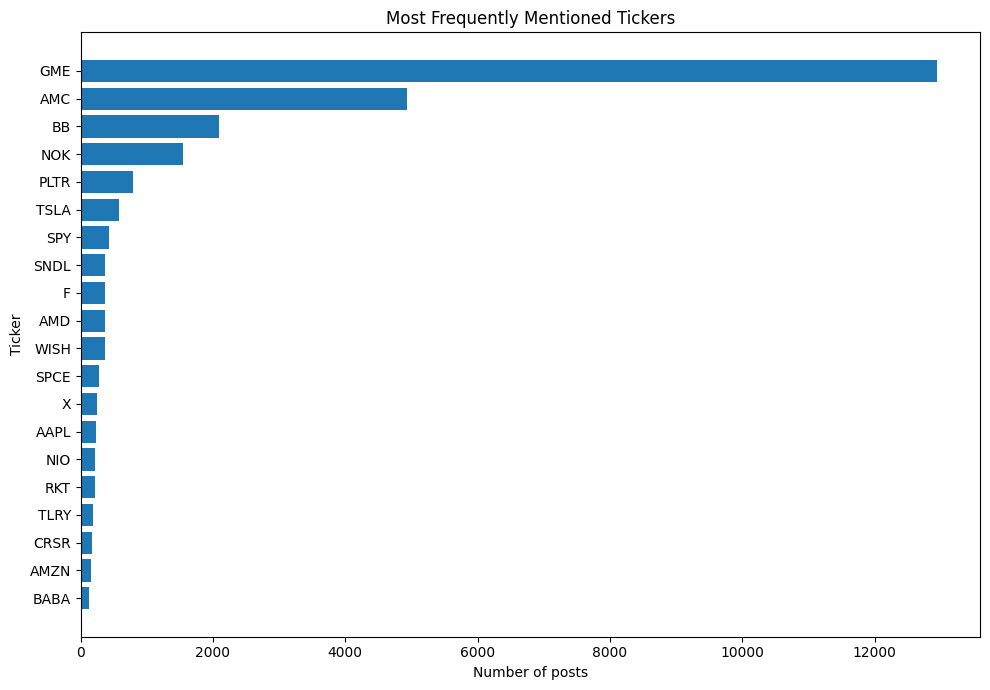

In [15]:
top_tickers = ticker_frequency_df.head(20).sort_values(
    "number_of_posts"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_tickers["ticker"],
    top_tickers["number_of_posts"]
)
plt.title("Most Frequently Mentioned Tickers")
plt.xlabel("Number of posts")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

### Ticker Mentions over Time

Aggregate frequency alone does not show when a security became popular. The following analysis measures daily attention and reveals sudden bursts of interest.


In [16]:
if "post_date" in analysis_df.columns:
    daily_ticker_mentions = (
        analysis_df[
            ["post_date", "tickers"]
        ]
        .explode("tickers")
        .dropna(subset=["tickers"])
        .groupby(
            ["post_date", "tickers"]
        )
        .size()
        .rename("mentions")
        .reset_index()
    )

    display(daily_ticker_mentions.head())

,post_date,tickers,mentions
0,2020-09-29 00:00:00+00:00,CBAT,1
1,2020-09-29 00:00:00+00:00,OXBR,1
2,2020-09-29 00:00:00+00:00,SPI,1
3,2020-09-29 00:00:00+00:00,SUNW,1
4,2021-01-28 00:00:00+00:00,AAL,1


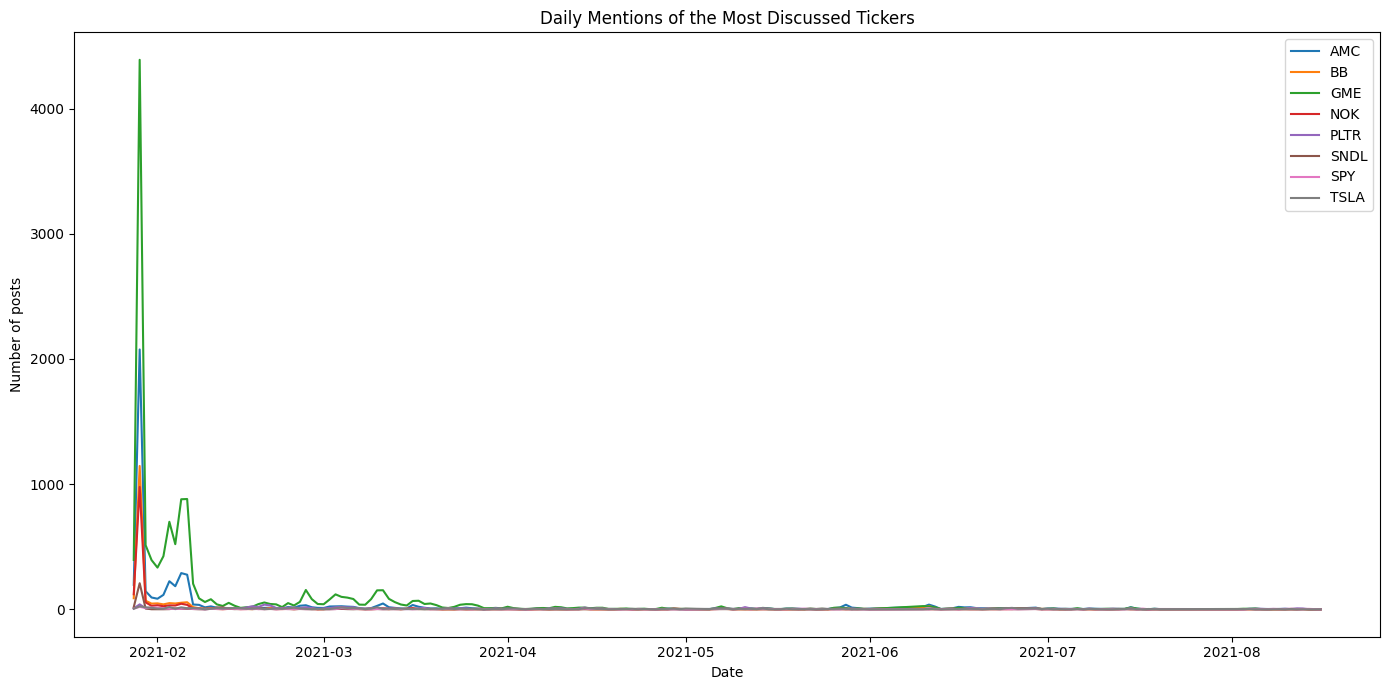

In [17]:
if "post_date" in analysis_df.columns:
    most_common_tickers = (
        ticker_frequency_df.head(8)["ticker"].tolist()
    )

    ticker_time_matrix = (
        daily_ticker_mentions[
            daily_ticker_mentions["tickers"].isin(
                most_common_tickers
            )
        ]
        .pivot(
            index="post_date",
            columns="tickers",
            values="mentions"
        )
        .fillna(0)
    )

    plt.figure(figsize=(14, 7))

    for ticker in ticker_time_matrix.columns:
        plt.plot(
            ticker_time_matrix.index,
            ticker_time_matrix[ticker],
            label=ticker
        )

    plt.title("Daily Mentions of the Most Discussed Tickers")
    plt.xlabel("Date")
    plt.ylabel("Number of posts")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Baseline Sentiment Analysis with VADER

Sentiment analysis estimates the emotional polarity expressed in a post. VADER is a useful baseline because it was designed for short social-media text and recognises punctuation, capitalisation, and intensifiers.

However, VADER is not specifically trained on financial language. Its results should therefore be treated as a baseline rather than definitive investment sentiment.


In [18]:
import nltk

nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

In [19]:
def vader_sentiment(text):
    scores = vader.polarity_scores(text)

    compound = scores["compound"]

    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"

    return pd.Series({
        "vader_negative": scores["neg"],
        "vader_neutral": scores["neu"],
        "vader_positive": scores["pos"],
        "vader_compound": compound,
        "vader_label": label
    })


vader_results = analysis_df["full_text"].apply(
    vader_sentiment
)

analysis_df = pd.concat(
    [
        analysis_df,
        vader_results
    ],
    axis=1
)

display(
    analysis_df[
        [
            "full_text",
            "vader_compound",
            "vader_label"
        ]
    ].head(10)
)

,full_text,vader_compound,vader_label
0,"It's not about the money, it's about sending a message. 🚀💎🙌",0.0000,neutral
1,Math Professor Scott Steiner says the numbers spell DISASTER for Gamestop shorts,-0.7034,negative
2,Exit the system. The CEO of NASDAQ pushed to halt trading “to give investors a chance to recalibrate their positions”.\n\n[https://mobile.twitter.com/Mediaite/status/1354504710695362563](https://mobile.twitter.com/Mediaite/status/1354504710695362...,-0.4199,negative
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETARDED THAN ME PLEASE INTERPRET?,-0.3397,negative
4,"Not to distract from GME, just thought our AMC brothers should be aware of this",0.2235,positive
5,WE BREAKING THROUGH,0.0000,neutral
6,"SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE. Hedgefund whales are spreading disinfo saying Friday is make-or-break for $GME. Call options expiring ITM on Friday will drive the price up if levels are maintained, but may not trigger the short squee...",0.8663,positive
7,THIS IS THE MOMENT. Life isn't fair. My mother always told me that when I would complain about arbitrary treatment. I would play by the rules and someone else would ignore them. When they would win I would appeal to the first authority for an exp...,-0.9942,negative
8,Currently Holding AMC and NOK - Is it retarded that I think I should move it all to GME today?,-0.5719,negative
9,I have nothing to say but BRUH I am speechless TO THE MOON 🚀🚀🚀💎💎👋👋,0.0000,neutral


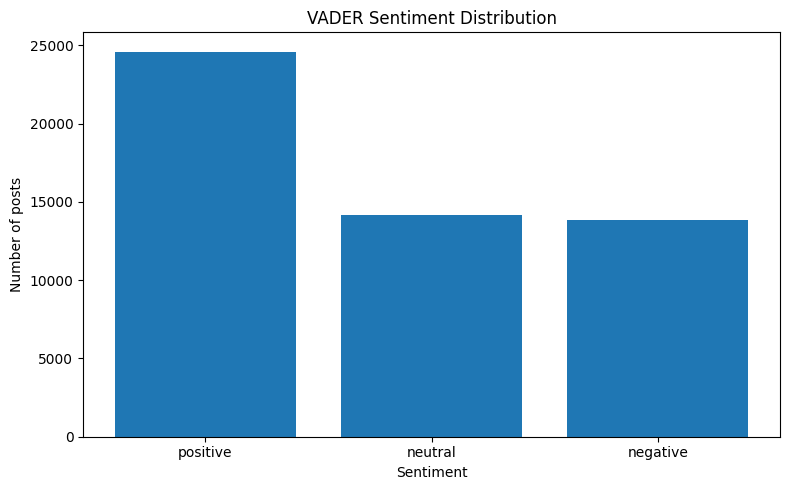

In [20]:
vader_distribution = (
    analysis_df["vader_label"]
    .value_counts()
    .reindex(
        ["positive", "neutral", "negative"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))
plt.bar(
    vader_distribution.index,
    vader_distribution.values
)
plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

### Sentiment over Time

Daily sentiment can help reveal periods of unusual optimism or pessimism. Both the average compound score and the number of daily posts should be considered, since a daily average based on very few observations may be unstable.


In [21]:
if "post_date" in analysis_df.columns:
    daily_sentiment = (
        analysis_df.groupby("post_date")
        .agg(
            average_sentiment=(
                "vader_compound",
                "mean"
            ),
            median_sentiment=(
                "vader_compound",
                "median"
            ),
            number_of_posts=(
                "vader_compound",
                "size"
            )
        )
        .reset_index()
    )

    daily_sentiment["rolling_sentiment_7d"] = (
        daily_sentiment["average_sentiment"]
        .rolling(
            window=7,
            min_periods=1
        )
        .mean()
    )

    display(daily_sentiment.head())

,post_date,average_sentiment,median_sentiment,number_of_posts,rolling_sentiment_7d
0,2020-09-29 00:00:00+00:00,0.912700,0.9127,1,0.912700
1,2021-01-28 00:00:00+00:00,0.021637,0.0000,1196,0.467169
2,2021-01-29 00:00:00+00:00,-0.008541,0.0000,15507,0.308599
3,2021-01-30 00:00:00+00:00,0.152924,0.0000,1417,0.269680
4,2021-01-31 00:00:00+00:00,0.164870,0.0000,932,0.248718


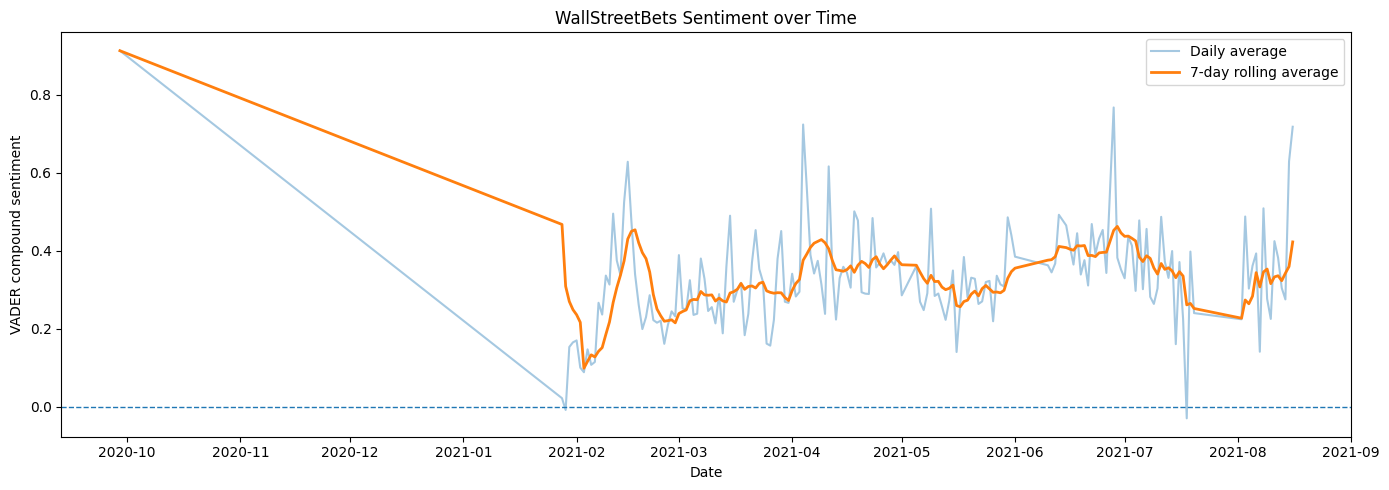

In [22]:
if "post_date" in analysis_df.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(
        daily_sentiment["post_date"],
        daily_sentiment["average_sentiment"],
        alpha=0.4,
        label="Daily average"
    )
    plt.plot(
        daily_sentiment["post_date"],
        daily_sentiment["rolling_sentiment_7d"],
        linewidth=2,
        label="7-day rolling average"
    )
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )
    plt.title("WallStreetBets Sentiment over Time")
    plt.xlabel("Date")
    plt.ylabel("VADER compound sentiment")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5. Financial Sentiment Analysis with FinBERT

FinBERT is a transformer model adapted to financial text. Comparing FinBERT with VADER makes it possible to investigate whether a domain-specific model interprets WallStreetBets language differently from a general social-media sentiment model.

The comparison is valuable because financial expressions do not always have the same meaning as ordinary positive or negative language. For example, a company being “cheap” may be interpreted negatively in everyday language but positively in an investment thesis.

Transformer inference can be computationally expensive. The code therefore uses batching and can initially be applied to a representative sample.


In [23]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

print(
    "Inference device:",
    "GPU" if device == 0 else "CPU"
)

Inference device: GPU


In [24]:
finbert_pipeline = pipeline(
    task="text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=device
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [25]:
def run_batched_classifier(
    texts,
    classifier,
    batch_size=32,
    max_characters=4000
):
    """
    Run transformer classification in batches.
    """
    prepared_texts = (
        texts.fillna("")
        .astype(str)
        .str.slice(0, max_characters)
        .tolist()
    )

    predictions = classifier(
        prepared_texts,
        batch_size=batch_size,
        truncation=True,
        max_length=512
    )

    return pd.DataFrame({
        "finbert_label": [
            prediction["label"].lower()
            for prediction in predictions
        ],
        "finbert_confidence": [
            prediction["score"]
            for prediction in predictions
        ]
    })

In [26]:
# Begin with a sample for faster notebook execution.
# Set FINBERT_SAMPLE_SIZE = len(analysis_df) for the complete corpus.

FINBERT_SAMPLE_SIZE = min(
    10000,
    len(analysis_df)
)

finbert_df = analysis_df.sample(
    FINBERT_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).copy()

finbert_results = run_batched_classifier(
    finbert_df["clean_text"],
    finbert_pipeline,
    batch_size=32
)

finbert_df = pd.concat(
    [
        finbert_df.reset_index(drop=True),
        finbert_results
    ],
    axis=1
)

display(
    finbert_df[
        [
            "full_text",
            "vader_label",
            "finbert_label",
            "finbert_confidence"
        ]
    ].head(10)
)

,full_text,vader_label,finbert_label,finbert_confidence
0,OH SHIT ITS A WAR BOIS,negative,neutral,0.713550
1,Remember that time you bought 12k riot and sold for pennies? 🤢🧻🤚,negative,neutral,0.926938
2,HOLD THE LINE!. If we sell they win. Buy $AMC!,positive,neutral,0.935951
3,"Daily option statistics for AMC, CLNE, BB, WISH, GME, WKHS, CLOV, PLTR, CLF, and others.. Hey guys,\n\nHere is the daily option statistics for the most talked about stocks on WSB.\n\nAcross the board we are having green on the big names. $AMC sho...",positive,neutral,0.892998
4,The Squeeze CASE for AMC just doesn't exist .. fundamental and technical analysis. **1.\tNo there is no real short squeeze possible**\n\nWhat you have seen is short term momentum trading – and this has very very short legs as seen before and as i...,positive,neutral,0.829311
5,We are at FUCKING WAR!. These big hedge funds and trading platforms think that 5 million autists can't beat them? We are in for the long haul! Fuck all these guys on the top trying to steal money from under our noses. We now have the backing from...,negative,neutral,0.772930
6,You degenerates are contagious - Fuck it. Buy that dip! 💎✋💎✋,negative,negative,0.523255
7,"Suggestion / Request for this subreddit. Given the large daily volume of posts, especially when there is one or more highly active stocks, would it be possible to have a sticky post that summarizes the different tickers that have been discussed? ...",positive,neutral,0.917859
8,"Some important advice for my fellow Canadian investors.. Maybe it was just me who didn't know this but put your investments/stocks into a RRSP or TFSA account immediately if you haven't already. If you currently just use a margin account, 50% o...",positive,neutral,0.817448
9,"At this point, yall are pathetic.. Party's over. Most people still here are bag holders who have convinced each other that 'sticking it to the man' was worth losing 6k of their 45k net worth.\n\nOr worse, they think it's still ""going to the moon""...",positive,neutral,0.663212


### Comparing VADER and FinBERT

Agreement between the models indicates posts whose polarity is relatively clear. Disagreement identifies linguistically difficult examples and is especially useful for qualitative error analysis.


In [27]:
sentiment_comparison = pd.crosstab(
    finbert_df["vader_label"],
    finbert_df["finbert_label"],
    normalize="index"
).round(3)

display(sentiment_comparison)

finbert_label,negative,neutral,positive
vader_label,,,
negative,0.226,0.754,0.020
neutral,0.055,0.888,0.057
positive,0.071,0.842,0.087


In [28]:
finbert_df["models_agree"] = (
    finbert_df["vader_label"]
    == finbert_df["finbert_label"]
)

agreement_rate = (
    finbert_df["models_agree"].mean()
)

print(
    f"VADER–FinBERT agreement: "
    f"{agreement_rate:.2%}"
)

VADER–FinBERT agreement: 33.64%


In [29]:
disagreement_examples = (
    finbert_df.loc[
        ~finbert_df["models_agree"],
        [
            "full_text",
            "vader_compound",
            "vader_label",
            "finbert_label",
            "finbert_confidence"
        ]
    ]
    .sort_values(
        "finbert_confidence",
        ascending=False
    )
)

display(disagreement_examples.head(20))

,full_text,vader_compound,vader_label,finbert_label,finbert_confidence
4940,Netflix reports dramatic slowdown in subscribers,0.0000,neutral,negative,0.973021
7185,CVAC stock falls over 50% in after hours trading after covid vaccine shows 47% efficacy,0.0000,neutral,negative,0.969614
9376,"All you have to do is hold!!! Gamestop Shares Down 63% as Large ShareHolder MUST Asset Management Reportedly Sells Stake, MarketWatch Says; AMC Drops 67% BY MT Newswires — 11:25 AM ET 01/28/2021",0.6784,positive,negative,0.969381
5179,"Should You Buy Corning Stock? With 5G and everything running off of fiber, Is this a good stock to invest in and why?. [https://www.forbes.com/sites/greatspeculations/2020/12/15/should-you-buy-corning-stock-at-36/?sh=6117ec611813](https://www.for...",0.9301,positive,negative,0.967950
4531,"🧐. Market shot down with hardly any sell orders compared to buy orders. Seems fishy🤔\n\nSloppy, Melvin. Sloppy",0.0000,neutral,negative,0.965559
7725,"(2/23) Tuesday's Pre-Market Stock Movers & News. #Good morning traders and investors of the r/wallstreetbets sub! Welcome to Tuesday! Here are your pre-market stock movers & news on this Tuesday, February 23, 2021-\n\n*****\n\n# [5 things to know...",0.9974,positive,negative,0.965441
4505,"but what if we try to invest in GOPRO? (GPRO). Shares of action-camera maker GoPro (NASDAQ:GPRO) sank more than 20% at their lows on Friday, and remained down 18.6% as of 3:30 p.m. EST. \n\nThe company announced its fourth-quarter earnings result...",0.9620,positive,negative,0.965263
1932,Seeing Your Account Is Down -30% In Pre-Market,0.0000,neutral,negative,0.964143
7558,"Stash is down. For over an hour, the Stash app has been unaccessable. The message says it is experiencing slow load times",0.0000,neutral,negative,0.964111
4135,UK Press also creating fear - HOLD. Front page of The Guardian UK\n\n1) Shares likely to fall [https://www.theguardian.com/business/2021/jan/28/gamestop-shares-robinhood-app-ban-blackberry-amc-nokia-reddit](https://www.theguardian.com/business/20...,0.0516,positive,negative,0.962765


### FinBERT Sentiment by Ticker

The next analysis associates each ticker mention with the sentiment of the corresponding post. This is more informative than calculating one global sentiment distribution for the entire community.


In [30]:
ticker_finbert_sentiment = (
    finbert_df[
        [
            "tickers",
            "finbert_label",
            "finbert_confidence"
        ]
    ]
    .explode("tickers")
    .dropna(subset=["tickers"])
    .groupby(
        ["tickers", "finbert_label"]
    )
    .agg(
        number_of_posts=(
            "finbert_label",
            "size"
        ),
        average_confidence=(
            "finbert_confidence",
            "mean"
        )
    )
    .reset_index()
)

display(
    ticker_finbert_sentiment.sort_values(
        "number_of_posts",
        ascending=False
    ).head(30)
)

,tickers,finbert_label,number_of_posts,average_confidence
225,GME,neutral,2076,0.820564
21,AMC,neutral,811,0.826134
58,BB,neutral,356,0.818212
224,GME,negative,275,0.688323
366,NOK,neutral,256,0.821842
20,AMC,negative,113,0.706377
411,PLTR,neutral,113,0.842817
226,GME,positive,101,0.735238
547,TSLA,neutral,91,0.800010
188,F,neutral,68,0.828329


In [31]:
ticker_sentiment_matrix = (
    ticker_finbert_sentiment.pivot(
        index="tickers",
        columns="finbert_label",
        values="number_of_posts"
    )
    .fillna(0)
)

ticker_sentiment_share = (
    ticker_sentiment_matrix.div(
        ticker_sentiment_matrix.sum(axis=1),
        axis=0
    )
)

top_sentiment_tickers = (
    ticker_sentiment_matrix.sum(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

display(
    ticker_sentiment_share.loc[
        top_sentiment_tickers
    ].round(3)
)

finbert_label,negative,neutral,positive
tickers,,,
GME,0.112,0.847,0.041
AMC,0.115,0.826,0.059
BB,0.108,0.854,0.038
NOK,0.115,0.821,0.064
PLTR,0.111,0.837,0.052
TSLA,0.113,0.791,0.096
SPY,0.143,0.798,0.060
WISH,0.089,0.810,0.101
F,0.040,0.907,0.053


## 6. Ticker-Level Bullish, Bearish, and Neutral Stance

Sentiment and investment stance are related but distinct concepts. A post can express fear about the wider market while remaining bullish on a specific company. Similarly, a positive description of a company may conclude that its shares are overvalued.

Stance detection focuses on the action or position communicated toward an investment:

* **Bullish:** expecting a price increase or recommending a long position;
* **Bearish:** expecting a decline or recommending a short position;
* **Neutral:** informational, uncertain, mixed, or lacking a clear position.

A rule-based system can create initial weak labels. These labels should subsequently be reviewed manually before being used as training data.


In [32]:
bullish_patterns = [
    r"\bbuy\b",
    r"\bbought\b",
    r"\bbullish\b",
    r"\blong\b",
    r"\bcall options?\b",
    r"\bcalls\b",
    r"\bundervalued\b",
    r"\bbreakout\b",
    r"\bshort squeeze\b",
    r"\bstrong hold\b",
    r"\bprice increase\b",
    r"\bupside\b",
    r"\baccumulate\b",
    r"\badding shares\b"
]

bearish_patterns = [
    r"\bsell\b",
    r"\bsold\b",
    r"\bbearish\b",
    r"\bshort\b",
    r"\bput options?\b",
    r"\bputs\b",
    r"\bovervalued\b",
    r"\bdump\b",
    r"\bcollapse\b",
    r"\bdownside\b",
    r"\bbankrupt(?:cy)?\b",
    r"\bprice decline\b",
    r"\btake profits\b"
]

In [33]:
def count_pattern_matches(text, patterns):
    return sum(
        bool(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
        )
        for pattern in patterns
    )


def weak_stance_label(text):
    bullish_score = count_pattern_matches(
        text,
        bullish_patterns
    )

    bearish_score = count_pattern_matches(
        text,
        bearish_patterns
    )

    if bullish_score > bearish_score:
        label = "bullish"
    elif bearish_score > bullish_score:
        label = "bearish"
    else:
        label = "neutral"

    return pd.Series({
        "bullish_rule_score": bullish_score,
        "bearish_rule_score": bearish_score,
        "weak_stance": label
    })


stance_results = analysis_df["clean_text"].apply(
    weak_stance_label
)

analysis_df = pd.concat(
    [
        analysis_df,
        stance_results
    ],
    axis=1
)

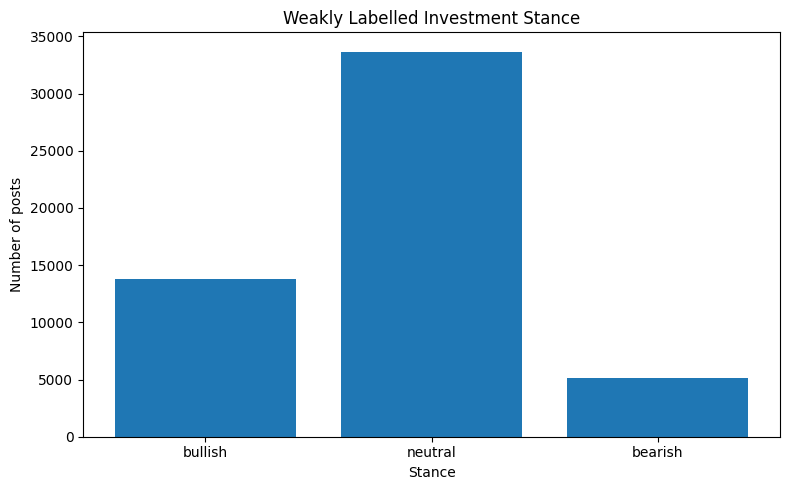

In [34]:
stance_distribution = (
    analysis_df["weak_stance"]
    .value_counts()
    .reindex(
        ["bullish", "neutral", "bearish"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))
plt.bar(
    stance_distribution.index,
    stance_distribution.values
)
plt.title("Weakly Labelled Investment Stance")
plt.xlabel("Stance")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

### Creating a Manual Annotation Sample

A reliable stance model requires manually verified examples. The following code creates a balanced annotation file containing posts from each weakly labelled category.

The reviewer should add a `stance_label` column and assign one of:

* `bullish`
* `bearish`
* `neutral`



In [35]:
annotation_parts = []

for stance_name, group in analysis_df.groupby(
    "weak_stance"
):
    sample_size = min(
        100,
        len(group)
    )

    sampled_group = group.sample(
        sample_size,
        random_state=RANDOM_STATE
    )

    annotation_parts.append(
        sampled_group
    )

stance_annotation_sample = (
    pd.concat(annotation_parts)
    [
        [
            "full_text",
            "tickers",
            "weak_stance",
            "bullish_rule_score",
            "bearish_rule_score"
        ]
    ]
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

stance_annotation_sample["stance_label"] = ""

display(stance_annotation_sample.head(15))

stance_annotation_sample.to_csv(
    "stance_annotation_sample.csv",
    index=False
)

,full_text,tickers,weak_stance,bullish_rule_score,bearish_rule_score,stance_label
0,"Metal Mania! Robots and Silver. So on last week while I was 💎 👐ing and checking on my ape brethren, I began to notice something . A ticker that had been gaining a little bit of traction in recent days, but nothing astounding.\n\n Not only did SLV...",[GME],neutral,0,0,
1,Bringing back u/A_SARCASM_DETECTOR post from 3 years ago LOL [ Perfect timing for it ],[],neutral,0,0,
2,"This is it, this is the last dip and it's to the MOON from here 🚀 $$$GME$$$. The stock has just reached a new low, so many people who were curious about buying can now afford it. From here it's only going to go up. Elon is going to drop a big bag...",[GME],bullish,1,0,
3,sold my wish for this…,[],bearish,0,1,
4,$GME LOSSES THREAD- Pre- Crash. A nice thread where your enormous losses can at least serve as entertainment :),[GME],neutral,0,0,
5,Upstart earnings today. Hope this goes up,[],neutral,0,0,
6,BUYING OPPORTUNITY.... CASHAPP is allowing to buy amc!!! 💪🏼,[],bullish,1,0,
7,NOK on TD Ameritrade!. Can still buy NOK on TD Ameritrade,[NOK],bullish,1,0,
8,Losses on short positions in U.S. firms top $70 billion,[],bearish,0,1,
9,I am seated on the AMC rocket awaiting take off to the moon 🚀🚀🚀🌕💎🙌,[AMC],bullish,1,0,


### Training a Stance Classifier

After the annotation file has been reviewed and uploaded back into the notebook, a TF-IDF logistic-regression classifier provides a strong and interpretable baseline.



In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [37]:
# Load the manually completed annotation file.
# Update the path if necessary.

ANNOTATION_PATH = (
    "/kaggle/input/wsb-stance-annotations/"
    "stance_annotation_sample.csv"
)

if os.path.exists(ANNOTATION_PATH):
    annotated_df = pd.read_csv(
        ANNOTATION_PATH
    )

    annotated_df = annotated_df[
        annotated_df["stance_label"].isin(
            ["bullish", "bearish", "neutral"]
        )
    ].copy()

    print(
        annotated_df["stance_label"]
        .value_counts()
    )
else:
    print(
        "Upload the manually annotated file "
        "before running this section."
    )

Upload the manually annotated file before running this section.


In [38]:
if "annotated_df" in globals() and len(annotated_df) >= 30:
    train_stance, test_stance = train_test_split(
        annotated_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=annotated_df["stance_label"]
    )

    stance_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=50000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])

    stance_model.fit(
        train_stance["full_text"],
        train_stance["stance_label"]
    )

    stance_predictions = stance_model.predict(
        test_stance["full_text"]
    )

    print(
        classification_report(
            test_stance["stance_label"],
            stance_predictions,
            digits=3
        )
    )

In [39]:
if "stance_predictions" in globals():
    ConfusionMatrixDisplay.from_predictions(
        test_stance["stance_label"],
        stance_predictions,
        normalize="true"
    )

    plt.title(
        "Normalised Confusion Matrix: "
        "Investment Stance"
    )
    plt.tight_layout()
    plt.show()

## 7. Post-Intent and Flair Classification

WallStreetBets contains several distinct types of communication. Some posts present detailed due diligence, while others report gains or losses, ask questions, share news, describe a position, or publish memes.

Classifying post intent provides a more informative view of the corpus than sentiment alone. If the dataset contains Reddit flair, the flair can be used as a noisy target label.

Because flair is assigned by authors or moderators and may not always match the actual content, the resulting model should be interpreted as a flair-prediction model rather than an absolute semantic truth.



In [40]:
if flair_col is not None:
    flair_distribution = (
        analysis_df[flair_col]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .rename_axis("flair")
        .reset_index(name="number_of_posts")
    )

    display(flair_distribution.head(25))
else:
    print("No flair column was detected.")

No flair column was detected.


In [41]:
if flair_col is not None:
    top_flairs = (
        flair_distribution.head(15)
        .sort_values("number_of_posts")
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_flairs["flair"],
        top_flairs["number_of_posts"]
    )
    plt.title("Most Frequent Post Flairs")
    plt.xlabel("Number of posts")
    plt.ylabel("Flair")
    plt.tight_layout()
    plt.show()

### Training the Flair Classifier

Very rare flair categories are removed because they do not provide enough examples for reliable evaluation.


In [42]:
if flair_col is not None:
    flair_model_df = (
        analysis_df[
            ["clean_text", flair_col]
        ]
        .dropna()
        .rename(
            columns={flair_col: "label"}
        )
    )

    flair_model_df["label"] = (
        flair_model_df["label"].astype(str)
    )

    minimum_class_size = 50

    valid_flairs = (
        flair_model_df["label"]
        .value_counts()
    )

    valid_flairs = valid_flairs[
        valid_flairs >= minimum_class_size
    ].index

    flair_model_df = flair_model_df[
        flair_model_df["label"].isin(
            valid_flairs
        )
    ].copy()

    print(
        "Number of retained flair classes:",
        flair_model_df["label"].nunique()
    )

    display(
        flair_model_df["label"]
        .value_counts()
        .head(20)
    )

In [43]:
if flair_col is not None and len(flair_model_df) > 0:
    train_flair, test_flair = train_test_split(
        flair_model_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=flair_model_df["label"]
    )

    flair_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.95,
                max_features=60000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])

    flair_model.fit(
        train_flair["clean_text"],
        train_flair["label"]
    )

    flair_predictions = flair_model.predict(
        test_flair["clean_text"]
    )

    print(
        classification_report(
            test_flair["label"],
            flair_predictions,
            digits=3,
            zero_division=0
        )
    )

### Examining Flair Misclassifications

A model’s errors can be more informative than its aggregate accuracy. Misclassified posts may reveal overlapping categories, inconsistent flair usage, sarcasm, insufficient text, or weaknesses in the feature representation.


In [44]:
if "flair_predictions" in globals():
    flair_errors = test_flair.copy()
    flair_errors["predicted_label"] = (
        flair_predictions
    )

    flair_errors = flair_errors[
        flair_errors["label"]
        != flair_errors["predicted_label"]
    ]

    display(
        flair_errors[
            [
                "clean_text",
                "label",
                "predicted_label"
            ]
        ].sample(
            min(20, len(flair_errors)),
            random_state=RANDOM_STATE
        )
    )

## 8. Contextual Topic Modelling with BERTopic

Topic modelling identifies recurring themes without requiring predefined labels. Traditional approaches such as latent Dirichlet allocation represent documents through word-frequency distributions. BERTopic instead uses contextual sentence embeddings, dimensionality reduction, clustering, and class-based TF-IDF.

This approach is well suited to short and informal posts because semantically similar messages can be grouped even when they do not use exactly the same vocabulary.

The analysis should focus not only on the most common topics but also on how those topics change over time.


In [45]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer

In [46]:
topic_candidates = analysis_df[
    analysis_df["clean_text"].str.len() >= 40
].copy()

TOPIC_SAMPLE_SIZE = min(
    20000,
    len(topic_candidates)
)

topic_df = topic_candidates.sample(
    TOPIC_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).copy()

topic_documents = (
    topic_df["clean_text"].tolist()
)

print(
    "Documents used for topic modelling:",
    len(topic_documents)
)

Documents used for topic modelling: 20000


In [47]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

topic_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=topic_vectorizer,
    min_topic_size=40,
    calculate_probabilities=False,
    verbose=True
)

topics, topic_probabilities = (
    topic_model.fit_transform(
        topic_documents
    )
)

topic_df["topic"] = topics

topic_information = (
    topic_model.get_topic_info()
)

display(
    topic_information.head(20)
)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-08-05 13:13:58,111 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

2026-08-05 13:14:28,418 - BERTopic - Embedding - Completed ✓
2026-08-05 13:14:28,420 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 13:15:03,735 - BERTopic - Dimensionality - Completed ✓
2026-08-05 13:15:03,737 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 13:15:07,798 - BERTopic - Cluster - Completed ✓
2026-08-05 13:15:07,809 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 13:15:11,880 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,8652,-1_shares_market_robinhood_people,"[shares, market, robinhood, people, stocks, short, trading, company, investors, retail]","[Cramer is working hard to take down videos of his admission to securities manipulating in a 2006 interview. Plenty of you degenerates have seen the interview from 2006 where Jim Cramer talks about about stock manipulation being a ""fun game"" from..."
1,0,1010,0_short_shorts_hedge_shares,"[short, shorts, hedge, shares, funds, hedge funds, squeeze, volume, retail, people]",[Ladder Selling Explained. Source: Gerald Klein - Forty year career in finance and executive management beginning on Coopers & Lybrand audit staff (CPA) culminating with twenty-six years as CEO of publicly-held companies. Abusive shorting are not...
2,1,837,1_price increase_bought_strong_bought gme,"[price increase, bought, strong, bought gme, increase, strong price, holding, gme strong, buy gme, hold gme]","[YOU CAN STILL BUY! LETS TAKE GME strong price increase!!!!, Hold GME strong price increase. We're coming for $300 today 🙌💎🚀🚀🚀, Keep buying and HOLD! GME strong price increase!!]"
3,2,736,2_ticker_gme_ticker_amc_ticker_bb_risk investment,"[ticker_gme, ticker_amc, ticker_bb, risk investment, high risk, investment, blockbuster, risk, high, ticker_nok]","[My final TICKER_WISH high risk investment, TICKER_XSPA all inn! Next TICKER_GME - go go go!!. 🚀🚀🚀, 106k TICKER_MSOS high risk investment 🚀🚀🚀 🤑🤑🤑]"
4,3,682,3_company_growth_revenue_amd,"[company, growth, revenue, amd, earnings, year, market, billion, million, share]","[Google Stock Analysis [Full due diligence]🚀 Is Google Stock a BUY right now?🚀. In this post we are going to go through an in-depth analysis of Google, we are going to take a look at their fundamental value, their Discounted Free Cash Flow, do a ..."
5,4,566,4_amzn_amc_movie_theaters,"[amzn, amc, movie, theaters, shares, movies, bought, theater, increase, investors]","[Buy AMC while it’s low AMC strong price increase🚀🚀🚀📈📈📈, AMC. Your thoughts on AMC? Can we push them?, CTRM. CTRM is going to be the next AMC get in now!!!!]"
6,5,433,5_holding_hold line_line_hold hold,"[holding, hold line, line, hold hold, strong, retards, strong hold, boys, doge, holding holding]","[All of Reddit is holding with us! Thank you to the other communities holding the line! strong hold!!, STILL HOLDING FROM 🇨🇦!! WE CAN DO THIS TOGETHER!!, UPVOTE IF YOU HAVE strong hold, HOLD THE LINE]"
7,6,346,6_gamestop_games_game_gaming,"[gamestop, games, game, gaming, company, cohen, sales, ryan, chewy, market]","[Why to REALLY buy GME (Solid due diligence). LEGITIMATE ARGUMENT TO INVEST IN GME AT THESE PRICES (Short sqeeze and hype aren't reasons). Sherman started a turnaround of Gamestop when he first took over April 2019. He cut the dividend, began con..."
8,7,332,7_amc_gme amc_amc gme_bb,"[amc, gme amc, amc gme, bb, nok, amc bb, strong, gme bb, amc nok, price increase]","[Which is smoke and mirrors?. So, I keep running scenarios through my head. I’m trying to understand why GME and AMC spiked 100’s % points a few weeks ago and then trading very similar to each to each other and both made moves this week. Is GME s..."
9,8,328,8_wsb_user_sub_tattoo,"[wsb, user, sub, tattoo, posts, mods, post, bots, reddit, subreddit]","[The only way to save WSB?. The very nature of this subreddit means its sentiment is an attractive product for manipulation. Twitter and Facebook have been actively filled with bots for years, or even ""farms"" of real humans doing the typing. It's..."


### Inspecting Representative Documents

A topic name based only on its most frequent terms may be misleading. Representative posts provide the context required to assign a meaningful human-readable label.


In [48]:
for topic_id in topic_information[
    topic_information["Topic"] != -1
]["Topic"].head(10):
    print("=" * 80)
    print(f"Topic {topic_id}")
    print(topic_model.get_topic(topic_id)[:10])

    representative_documents = (
        topic_model.get_representative_docs(
            topic_id
        )
    )

    for document in representative_documents[:3]:
        print("-", document[:500])
        print()

Topic 0
[('short', np.float64(0.026119060192624614)), ('shorts', np.float64(0.016811453463347708)), ('hedge', np.float64(0.015823071203167005)), ('shares', np.float64(0.013170609178123526)), ('funds', np.float64(0.012794044819646688)), ('hedge funds', np.float64(0.0122771710146156)), ('squeeze', np.float64(0.011654747839558307)), ('volume', np.float64(0.010499762804465804)), ('retail', np.float64(0.010018326226758712)), ('people', np.float64(0.008688569243782725))]
- Ladder Selling Explained. Source: Gerald Klein - Forty year career in finance and executive management beginning on Coopers & Lybrand audit staff (CPA) culminating with twenty-six years as CEO of publicly-held companies. Abusive shorting are not random acts of a renegade hedge funds, but rather a coordinated business plan that is carried out by a collusive consortium of hedge funds and prime brokers, with help from their friends at the DTC and major clearinghouses. Potential target companies are

- Some Onboarding for all 

In [49]:
# Interactive BERTopic visualisation.
topic_model.visualize_barchart(
    top_n_topics=12,
    n_words=10
)

In [50]:
topic_model.visualize_topics()

### Topics over Time

Topic evolution reveals which narratives appeared early, which persisted, and which emerged only during particular periods of market attention.


In [51]:
if "post_datetime" in topic_df.columns:
    valid_topic_dates = (
        topic_df["post_datetime"].notna()
    )

    topics_over_time = (
        topic_model.topics_over_time(
            topic_df.loc[
                valid_topic_dates,
                "clean_text"
            ].tolist(),
            topic_df.loc[
                valid_topic_dates,
                "post_datetime"
            ].tolist(),
            nr_bins=20
        )
    )

    display(topics_over_time.head())
else:
    print(
        "Temporal topic analysis requires "
        "a valid post date."
    )


20it [00:07,  2.84it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"robinhood, shares, market, people, stocks",5507,2021-01-28 04:20:14.916000+00:00
1,0,"short, shorts, hedge, funds, hedge funds",791,2021-01-28 04:20:14.916000+00:00
2,1,"price increase, bought, strong, bought gme, strong price",622,2021-01-28 04:20:14.916000+00:00
3,2,"ticker_gme, ticker_amc, ticker_bb, blockbuster, ticker_nok",332,2021-01-28 04:20:14.916000+00:00
4,3,"company, earnings, growth, revenue, amd",66,2021-01-28 04:20:14.916000+00:00


In [52]:
if "topics_over_time" in globals():
    topic_model.visualize_topics_over_time(
        topics_over_time,
        top_n_topics=10
    )

## 9. Emerging Narratives and Attention Spikes

Financial discussions are often characterised by sudden increases in attention. A ticker that normally appears in a few posts per day may abruptly be mentioned hundreds of times.

A rolling z-score compares the current number of mentions with the ticker’s recent history. High values identify attention levels that are unusual relative to the preceding window.

The statistic should be interpreted as an attention anomaly, not as proof of manipulation or future price movement.


In [53]:
if "post_date" in analysis_df.columns:
    daily_ticker_activity = (
        analysis_df[
            ["post_date", "tickers"]
        ]
        .explode("tickers")
        .dropna(subset=["tickers"])
        .groupby(
            ["post_date", "tickers"]
        )
        .size()
        .rename("mentions")
        .reset_index()
        .sort_values(
            ["tickers", "post_date"]
        )
    )

    display(
        daily_ticker_activity.head()
    )

,post_date,tickers,mentions
5585,2021-06-25 00:00:00+00:00,AA,1
4,2021-01-28 00:00:00+00:00,AAL,1
56,2021-01-29 00:00:00+00:00,AAL,24
213,2021-01-30 00:00:00+00:00,AAL,1
317,2021-02-01 00:00:00+00:00,AAL,1


In [54]:
if "daily_ticker_activity" in globals():
    daily_ticker_activity[
        "rolling_mean_7d"
    ] = (
        daily_ticker_activity.groupby(
            "tickers"
        )["mentions"]
        .transform(
            lambda values: (
                values.shift(1)
                .rolling(
                    window=7,
                    min_periods=3
                )
                .mean()
            )
        )
    )

    daily_ticker_activity[
        "rolling_std_7d"
    ] = (
        daily_ticker_activity.groupby(
            "tickers"
        )["mentions"]
        .transform(
            lambda values: (
                values.shift(1)
                .rolling(
                    window=7,
                    min_periods=3
                )
                .std()
            )
        )
    )

    daily_ticker_activity[
        "mention_zscore"
    ] = (
        daily_ticker_activity["mentions"]
        - daily_ticker_activity[
            "rolling_mean_7d"
        ]
    ) / daily_ticker_activity[
        "rolling_std_7d"
    ].replace(0, np.nan)

In [55]:
if "daily_ticker_activity" in globals():
    attention_spikes = (
        daily_ticker_activity[
            daily_ticker_activity[
                "mention_zscore"
            ] >= 3
        ]
        .sort_values(
            "mention_zscore",
            ascending=False
        )
    )

    display(
        attention_spikes.head(30)
    )

,post_date,tickers,mentions,rolling_mean_7d,rolling_std_7d,mention_zscore
5745,2021-06-29 00:00:00+00:00,SOFI,22,1.142857,0.377964,55.182813
4914,2021-06-10 00:00:00+00:00,WISH,26,1.285714,0.755929,32.693927
2021,2021-03-03 00:00:00+00:00,RKT,60,2.571429,2.225395,25.806018
5121,2021-06-16 00:00:00+00:00,DKNG,12,1.285714,0.487950,21.957752
3854,2021-04-27 00:00:00+00:00,MVIS,8,1.142857,0.377964,18.142295
6704,2021-08-13 00:00:00+00:00,WISH,14,1.428571,0.786796,15.978007
6240,2021-07-15 00:00:00+00:00,GME,14,2.714286,0.755929,14.929597
4118,2021-05-06 00:00:00+00:00,PLTR,7,1.285714,0.487950,11.710801
5679,2021-06-26 00:00:00+00:00,SPCE,14,2.000000,1.154701,10.392305
6392,2021-08-02 00:00:00+00:00,AMD,5,1.142857,0.377964,10.205041


### Engagement-Weighted Hype Score

Post volume treats every submission equally. An alternative measure weights posts by their engagement.

The following exploratory hype score combines:

* ticker mention frequency;
* logarithmically transformed post score;
* logarithmically transformed comment count;
* positive sentiment.

This score is a descriptive indicator created for the notebook. It is not a validated trading signal.



In [56]:
analysis_df["engagement_score"] = 0.0

if score_col is not None:
    numeric_score = pd.to_numeric(
        analysis_df[score_col],
        errors="coerce"
    ).fillna(0)

    analysis_df["engagement_score"] += (
        np.log1p(
            numeric_score.clip(lower=0)
        )
    )

if comments_col is not None:
    numeric_comments = pd.to_numeric(
        analysis_df[comments_col],
        errors="coerce"
    ).fillna(0)

    analysis_df["engagement_score"] += (
        np.log1p(
            numeric_comments.clip(lower=0)
        )
    )

sentiment_multiplier = (
    1
    + analysis_df["vader_compound"]
      .clip(lower=0)
)

analysis_df["hype_component"] = (
    analysis_df["engagement_score"]
    * sentiment_multiplier
)

In [57]:
if "post_date" in analysis_df.columns:
    daily_ticker_hype = (
        analysis_df[
            [
                "post_date",
                "tickers",
                "hype_component"
            ]
        ]
        .explode("tickers")
        .dropna(subset=["tickers"])
        .groupby(
            ["post_date", "tickers"]
        )
        .agg(
            number_of_posts=(
                "tickers",
                "size"
            ),
            hype_score=(
                "hype_component",
                "sum"
            )
        )
        .reset_index()
    )

    display(
        daily_ticker_hype.sort_values(
            "hype_score",
            ascending=False
        ).head(30)
    )

,post_date,tickers,number_of_posts,hype_score
113,2021-01-29 00:00:00+00:00,GME,4391,16518.675378
438,2021-02-03 00:00:00+00:00,GME,699,7843.355762
235,2021-01-30 00:00:00+00:00,GME,512,7805.307260
659,2021-02-06 00:00:00+00:00,GME,881,7048.006034
583,2021-02-05 00:00:00+00:00,GME,879,7017.731860
65,2021-01-29 00:00:00+00:00,AMC,2076,6928.691706
285,2021-01-31 00:00:00+00:00,GME,393,5958.377950
506,2021-02-04 00:00:00+00:00,GME,520,5413.605078
334,2021-02-01 00:00:00+00:00,GME,333,5171.703814
375,2021-02-02 00:00:00+00:00,GME,424,5116.106876


## 10. Semantic Search for Similar Posts

Keyword search retrieves documents that contain the same words. Semantic search retrieves posts that express similar meanings, even when they use different vocabulary.

This section converts each post into a dense sentence embedding and indexes the embeddings using FAISS. A user can then enter an investment claim, company thesis, or market concern and retrieve the most semantically similar historical posts.


In [58]:
import faiss
from sentence_transformers import SentenceTransformer

In [59]:
semantic_candidates = (
    analysis_df[
        analysis_df["clean_text"].str.len() >= 40
    ]
    .drop_duplicates(
        subset="clean_text"
    )
    .copy()
)

SEMANTIC_SAMPLE_SIZE = min(
    25000,
    len(semantic_candidates)
)

semantic_df = (
    semantic_candidates.sample(
        SEMANTIC_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

print(
    "Documents in semantic index:",
    len(semantic_df)
)

Documents in semantic index: 25000


In [60]:
semantic_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

semantic_embeddings = (
    semantic_model.encode(
        semantic_df["clean_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    .astype("float32")
)

print(
    "Embedding matrix shape:",
    semantic_embeddings.shape
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding matrix shape: (25000, 384)


In [61]:
semantic_index = faiss.IndexFlatIP(
    semantic_embeddings.shape[1]
)

semantic_index.add(
    semantic_embeddings
)

print(
    "Indexed documents:",
    semantic_index.ntotal
)

Indexed documents: 25000


In [62]:
def find_similar_posts(query, k=5):
    """
    Retrieve the k most semantically similar posts.
    """
    query_embedding = semantic_model.encode(
        [query],
        normalize_embeddings=True
    ).astype("float32")

    similarities, positions = (
        semantic_index.search(
            query_embedding,
            k
        )
    )

    results = semantic_df.iloc[
        positions[0]
    ].copy()

    results["semantic_similarity"] = (
        similarities[0]
    )

    selected_columns = [
        "full_text",
        "tickers",
        "semantic_similarity"
    ]

    if score_col is not None:
        selected_columns.append(score_col)

    return results[
        selected_columns
    ].reset_index(drop=True)

In [63]:
query = (
    "GameStop appears undervalued and "
    "may experience a short squeeze"
)

similar_posts = find_similar_posts(
    query,
    k=10
)

display(similar_posts)

,full_text,tickers,semantic_similarity,score
0,Why Gamestop is worth all this money.... Cause Gamestop got games,[],0.696738,1
1,OC: I made a video to help explain to people what a short squeeze is and what happened with GameStop over the past few weeks. Feedback welcome!,[],0.688704,0
2,GameStop stock worth $359 million 'failed to deliver' following frenzied short-squeeze,[],0.687416,7701
3,Can GameStop as a company turn their business model around and become profitable again. GameStop needs to evolve into a technology company that delights gamers and delivers exceptional digital experiences—not remain a video game retailer that ove...,[HIT],0.684105,334
4,GameStop Stock Is Holding Up. Skeptics Remain,[],0.670826,2792
5,"[Yahoo Finance, Feb 1] Why GameStop's stock could rise much, much higher",[],0.668151,1019
6,"GameStop won’t stop, buying GameStop! Why? I like this stock!!💎🙌🚀to🌝we go",[],0.664779,3934
7,"In all honesty, what market cap do you think Gamestop belongs at?. Current valuation is at $4.7B. From 2016 up to the time WSB started its war against the Hedges, the valuation of the company reached max ~$3B. \nThe peak of the $450 pump, valuati...",[],0.659225,2
8,I’m late. Is it still a good idea to invest in GameStop?,[],0.646453,104
9,"GME: My easy to understand and short fundamentals analysis March 24. Not a financial advice\n\nI did company valuations before and have gotten pretty accurate estimates. While I’m doing this valuation on GME, I can tell that I like the fundamenta...",[GME],0.645721,1029


In [64]:
query = (
    "GameStop appears undervalued and "
    "may experience a short squeeze"
)

similar_posts = find_similar_posts(
    query,
    k=10
)

display(similar_posts)

,full_text,tickers,semantic_similarity,score
0,Why Gamestop is worth all this money.... Cause Gamestop got games,[],0.696738,1
1,OC: I made a video to help explain to people what a short squeeze is and what happened with GameStop over the past few weeks. Feedback welcome!,[],0.688704,0
2,GameStop stock worth $359 million 'failed to deliver' following frenzied short-squeeze,[],0.687416,7701
3,Can GameStop as a company turn their business model around and become profitable again. GameStop needs to evolve into a technology company that delights gamers and delivers exceptional digital experiences—not remain a video game retailer that ove...,[HIT],0.684105,334
4,GameStop Stock Is Holding Up. Skeptics Remain,[],0.670826,2792
5,"[Yahoo Finance, Feb 1] Why GameStop's stock could rise much, much higher",[],0.668151,1019
6,"GameStop won’t stop, buying GameStop! Why? I like this stock!!💎🙌🚀to🌝we go",[],0.664779,3934
7,"In all honesty, what market cap do you think Gamestop belongs at?. Current valuation is at $4.7B. From 2016 up to the time WSB started its war against the Hedges, the valuation of the company reached max ~$3B. \nThe peak of the $450 pump, valuati...",[],0.659225,2
8,I’m late. Is it still a good idea to invest in GameStop?,[],0.646453,104
9,"GME: My easy to understand and short fundamentals analysis March 24. Not a financial advice\n\nI did company valuations before and have gotten pretty accurate estimates. While I’m doing this valuation on GME, I can tell that I like the fundamenta...",[GME],0.645721,1029


## 11. Near-Duplicate and Coordinated-Narrative Detection

Some posts repeat identical or nearly identical claims. This may be caused by reposting, quotations, recurring news headlines, copied investment theses, bots, or coordinated narratives.

Character-level TF-IDF is useful for detecting near duplicates because it remains effective when users make small spelling, punctuation, or formatting changes.

The method does not determine why two posts are similar. High similarity should therefore trigger manual investigation rather than an automatic conclusion about coordination.


In [65]:
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)
from sklearn.neighbors import NearestNeighbors

In [66]:
duplicate_candidates = (
    analysis_df[
        analysis_df["clean_text"].str.len() >= 80
    ]
    .drop_duplicates(
        subset="clean_text"
    )
    .copy()
)

DUPLICATE_SAMPLE_SIZE = min(
    20000,
    len(duplicate_candidates)
)

duplicate_df = (
    duplicate_candidates.sample(
        DUPLICATE_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

print(
    "Documents used for duplicate detection:",
    len(duplicate_df)
)

Documents used for duplicate detection: 20000


In [67]:
duplicate_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

duplicate_matrix = (
    duplicate_vectorizer.fit_transform(
        duplicate_df["clean_text"]
    )
)

print(
    "TF-IDF matrix shape:",
    duplicate_matrix.shape
)

TF-IDF matrix shape: (20000, 100000)


In [68]:
nearest_neighbour_model = NearestNeighbors(
    n_neighbors=2,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)

nearest_neighbour_model.fit(
    duplicate_matrix
)

distances, neighbour_indices = (
    nearest_neighbour_model.kneighbors(
        duplicate_matrix
    )
)

duplicate_df["nearest_post_index"] = (
    neighbour_indices[:, 1]
)

duplicate_df["nearest_similarity"] = (
    1 - distances[:, 1]
)

In [69]:
similarity_threshold = 0.85

possible_duplicates = (
    duplicate_df[
        duplicate_df[
            "nearest_similarity"
        ] >= similarity_threshold
    ]
    .sort_values(
        "nearest_similarity",
        ascending=False
    )
    .copy()
)

possible_duplicates[
    "nearest_post_text"
] = possible_duplicates[
    "nearest_post_index"
].map(
    duplicate_df["full_text"]
)

display(
    possible_duplicates[
        [
            "full_text",
            "nearest_post_text",
            "nearest_similarity"
        ]
    ].head(20)
)

,full_text,nearest_post_text,nearest_similarity
4687,"Important fucking reminder.. Do NOT bet with money that you cannot fucking lose. \n\nHow is that so difficult to understand? If you’re taking out your mortgages, loans, and life savings and dumping it in this, you’re a fucking idiot. Don’t ever m...","Important fucking reminder.. Do NOT bet with money that you cannot fucking lose. \n\nHow is that so difficult to understand? If you’re taking out your mortgages, loans, and life savings and dumping it in this, you’re a fucking idiot. Don’t ever m...",1.000000
4663,"IMPORTANT FUCKING REMINDER.. Do NOT bet with money that you cannot fucking lose. \n\nHow is that so difficult to understand? If you’re taking out your mortgages, loans, and life savings and dumping it in this, you’re a fucking idiot. Don’t ever m...","Important fucking reminder.. Do NOT bet with money that you cannot fucking lose. \n\nHow is that so difficult to understand? If you’re taking out your mortgages, loans, and life savings and dumping it in this, you’re a fucking idiot. Don’t ever m...",1.000000
13457,"READ THIS. READ THIS\n\nIM NOT 100% SURE BUT THIS IS THE TACTIC.\n\nLet’s say they have 1,000,000 shares\n\nFor every 10,000 shares they sell, they drop the next 10,000 by $10 to the point that the stock is losing money and not being consistent a...","READ THIS. IM NOT 100% SURE BUT THIS IS THE TACTIC.\n\nLet’s say they have 1,000,000 shares\n\nFor every 10,000 shares they sell, they drop the next 10,000 by $10 to the point that the stock is losing money and not being consistent as it was. \n\...",0.999211
5936,"READ THIS. IM NOT 100% SURE BUT THIS IS THE TACTIC.\n\nLet’s say they have 1,000,000 shares\n\nFor every 10,000 shares they sell, they drop the next 10,000 by $10 to the point that the stock is losing money and not being consistent as it was. \n\...","READ THIS. READ THIS\n\nIM NOT 100% SURE BUT THIS IS THE TACTIC.\n\nLet’s say they have 1,000,000 shares\n\nFor every 10,000 shares they sell, they drop the next 10,000 by $10 to the point that the stock is losing money and not being consistent a...",0.999211
10893,"GSAT DD (It's the spectrum, stupid). This is all off the top of my head but it’s a basic outline of why I think GSAT is a big deal. There are a lot of people who understand the company better than I do, but I really think this is worth looking se...","GSAT ULTIMATE DD. This is all off the top of my head but it’s a basic outline of why I think GSAT is a big deal. There are a lot of people who understand the company better than I do, but I really think this is worth looking seriously at, and its...",0.998385
16561,"GSAT ULTIMATE DD. This is all off the top of my head but it’s a basic outline of why I think GSAT is a big deal. There are a lot of people who understand the company better than I do, but I really think this is worth looking seriously at, and its...","GSAT DD (It's the spectrum, stupid). This is all off the top of my head but it’s a basic outline of why I think GSAT is a big deal. There are a lot of people who understand the company better than I do, but I really think this is worth looking se...",0.998385
5767,"Ex-PLTR Engineer DD Part #2: Usability, Deployabilty, Scalability, & Submersibility + My Lockup Plan. Honestly, this DD requires a lot of critical thinking. If that’s not your jam, please enjoy this cartoon of Alex Karp crushing the competition, ...","Former PLTR Engineer DD Part #2: Usability, Deployabilty, Scalability, & Submersibility + My Lockup Plan. Honestly, this DD requires a lot of critical thinking. If that’s not your jam, please enjoy this cartoon of Alex Karp crushing the competiti...",0.998376
4041,"Former PLTR Engineer DD Part #2: Usability, Deployabilty, Scalability, & Submersibility + My Lockup Plan. Honestly, this DD requires a lot of critical thinking. If that’s not your jam, please enjoy this cartoon of Alex Karp crushing the competiti...","Ex-PLTR Engineer DD Part #2: Usability, Deployabilty, Scalability

### Creating Duplicate Groups

The previous method retrieves the nearest neighbour for each post. Network connected components can be used to combine similar pairs into larger groups.


In [70]:
import networkx as nx

duplicate_graph = nx.Graph()

for row_index, row in possible_duplicates.iterrows():
    duplicate_graph.add_edge(
        row_index,
        int(row["nearest_post_index"]),
        weight=float(
            row["nearest_similarity"]
        )
    )

duplicate_groups = [
    component
    for component in nx.connected_components(
        duplicate_graph
    )
    if len(component) >= 2
]

print(
    "Number of duplicate groups:",
    len(duplicate_groups)
)

Number of duplicate groups: 171


In [71]:
for group_number, component in enumerate(
    duplicate_groups[:10],
    start=1
):
    print("=" * 80)
    print(
        f"Potential duplicate group "
        f"{group_number}"
    )

    group_posts = duplicate_df.loc[
        list(component),
        "full_text"
    ]

    for post in group_posts:
        print("-", post[:600])
        print()

Potential duplicate group 1
- IMPORTANT FUCKING REMINDER.. Do NOT bet with money that you cannot fucking lose. 

How is that so difficult to understand? If you’re taking out your mortgages, loans, and life savings and dumping it in this, you’re a fucking idiot. Don’t ever make this mistake ever again. You’re risking a lot, that you cannot afford to risk. Think about it twice, thrice, multiple times before diving in. This is not a for sure thing. Nobody fucking knows what’s going to happen. So please, for the love of god, do not bet with money you cannot afford to lose. It’s not worth it. It never will be. 

With that said,

- Important fucking reminder.. Do NOT bet with money that you cannot fucking lose. 

How is that so difficult to understand? If you’re taking out your mortgages, loans, and life savings and dumping it in this, you’re a fucking idiot. Don’t ever make this mistake ever again. You’re risking a lot, that you cannot afford to risk. Think about it twice, thrice, multiple 

## 12. Emotion Classification

Positive and negative sentiment provide only a broad representation of emotional language. WallStreetBets discussions may reflect fear, excitement, confidence, uncertainty, anger, regret, and humour.

A zero-shot classifier allows these categories to be explored without a dedicated labelled dataset. The model receives candidate labels and estimates which description best matches each post.

These outputs should be described as exploratory model-generated labels. They are not verified psychological measurements.



In [72]:
from transformers import pipeline

emotion_pipeline = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

emotion_labels = [
    "fear",
    "excitement",
    "confidence",
    "uncertainty",
    "anger",
    "regret",
    "humor"
]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [73]:
def classify_emotion(text):
    """
    Return the highest-scoring zero-shot emotion.
    """
    result = emotion_pipeline(
        text[:3000],
        candidate_labels=emotion_labels,
        multi_label=False
    )

    return pd.Series({
        "predicted_emotion": (
            result["labels"][0]
        ),
        "emotion_confidence": (
            result["scores"][0]
        )
    })

In [74]:
def classify_emotion(text):
    """
    Return the highest-scoring zero-shot emotion.
    """
    result = emotion_pipeline(
        text[:3000],
        candidate_labels=emotion_labels,
        multi_label=False
    )

    return pd.Series({
        "predicted_emotion": (
            result["labels"][0]
        ),
        "emotion_confidence": (
            result["scores"][0]
        )
    })

In [75]:
EMOTION_SAMPLE_SIZE = min(
    1000,
    len(analysis_df)
)

emotion_df = analysis_df.sample(
    EMOTION_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).copy()

emotion_results = (
    emotion_df["clean_text"]
    .apply(classify_emotion)
)

emotion_df = pd.concat(
    [
        emotion_df.reset_index(drop=True),
        emotion_results.reset_index(drop=True)
    ],
    axis=1
)

display(
    emotion_df[
        [
            "full_text",
            "predicted_emotion",
            "emotion_confidence"
        ]
    ].head(15)
)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,full_text,predicted_emotion,emotion_confidence
0,OH SHIT ITS A WAR BOIS,anger,0.349377
1,Remember that time you bought 12k riot and sold for pennies? 🤢🧻🤚,humor,0.485846
2,HOLD THE LINE!. If we sell they win. Buy $AMC!,uncertainty,0.626604
3,"Daily option statistics for AMC, CLNE, BB, WISH, GME, WKHS, CLOV, PLTR, CLF, and others.. Hey guys,\n\nHere is the daily option statistics for the most talked about stocks on WSB.\n\nAcross the board we are having green on the big names. $AMC sho...",excitement,0.273396
4,The Squeeze CASE for AMC just doesn't exist .. fundamental and technical analysis. **1.\tNo there is no real short squeeze possible**\n\nWhat you have seen is short term momentum trading – and this has very very short legs as seen before and as i...,uncertainty,0.364931
5,We are at FUCKING WAR!. These big hedge funds and trading platforms think that 5 million autists can't beat them? We are in for the long haul! Fuck all these guys on the top trying to steal money from under our noses. We now have the backing from...,anger,0.403561
6,You degenerates are contagious - Fuck it. Buy that dip! 💎✋💎✋,excitement,0.494448
7,"Suggestion / Request for this subreddit. Given the large daily volume of posts, especially when there is one or more highly active stocks, would it be possible to have a sticky post that summarizes the different tickers that have been discussed? ...",uncertainty,0.264188
8,"Some important advice for my fellow Canadian investors.. Maybe it was just me who didn't know this but put your investments/stocks into a RRSP or TFSA account immediately if you haven't already. If you currently just use a margin account, 50% o...",uncertainty,0.261029
9,"At this point, yall are pathetic.. Party's over. Most people still here are bag holders who have convinced each other that 'sticking it to the man' was worth losing 6k of their 45k net worth.\n\nOr worse, they think it's still ""going to the moon""...",uncertainty,0.340809


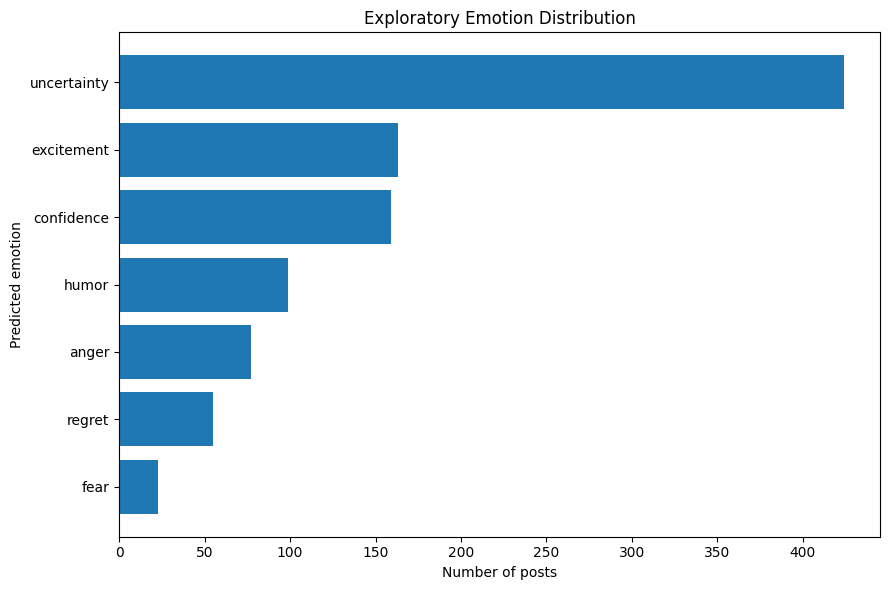

In [76]:
emotion_distribution = (
    emotion_df["predicted_emotion"]
    .value_counts()
    .reindex(
        emotion_labels,
        fill_value=0
    )
    .sort_values()
)

plt.figure(figsize=(9, 6))
plt.barh(
    emotion_distribution.index,
    emotion_distribution.values
)
plt.title(
    "Exploratory Emotion Distribution"
)
plt.xlabel("Number of posts")
plt.ylabel("Predicted emotion")
plt.tight_layout()
plt.show()

### Emotion by Ticker


In [77]:
ticker_emotion = (
    emotion_df[
        [
            "tickers",
            "predicted_emotion"
        ]
    ]
    .explode("tickers")
    .dropna(subset=["tickers"])
    .groupby(
        ["tickers", "predicted_emotion"]
    )
    .size()
    .rename("number_of_posts")
    .reset_index()
)

display(
    ticker_emotion.sort_values(
        "number_of_posts",
        ascending=False
    ).head(30)
)

,tickers,predicted_emotion,number_of_posts
66,GME,uncertainty,123
11,AMC,uncertainty,47
62,GME,excitement,30
61,GME,confidence,28
64,GME,humor,23
6,AMC,confidence,21
29,BB,uncertainty,19
60,GME,anger,17
7,AMC,excitement,15
101,NOK,uncertainty,15


## 13. Predicting High-Engagement Posts

The final supervised task investigates whether textual content can help identify posts that receive unusually high engagement.

A post is labelled as high engagement when its score falls within the top quartile. The classifier uses only text features, allowing the analysis to test whether linguistic patterns are associated with later popularity.

A chronological split is preferred to a random split. Random splitting may place highly similar posts or time-specific expressions in both training and test sets, leading to overly optimistic results.

This task identifies association, not causality. The model does not prove that particular words cause engagement.


In [78]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [79]:
if score_col is not None:
    engagement_df = analysis_df.copy()

    engagement_df[
        "numeric_post_score"
    ] = pd.to_numeric(
        engagement_df[score_col],
        errors="coerce"
    )

    engagement_df = engagement_df.dropna(
        subset=[
            "numeric_post_score",
            "clean_text"
        ]
    )

    high_engagement_threshold = (
        engagement_df[
            "numeric_post_score"
        ].quantile(0.75)
    )

    engagement_df[
        "high_engagement"
    ] = (
        engagement_df[
            "numeric_post_score"
        ] >= high_engagement_threshold
    ).astype(int)

    print(
        "High-engagement score threshold:",
        high_engagement_threshold
    )

    print(
        engagement_df[
            "high_engagement"
        ].value_counts(normalize=True)
    )
else:
    print(
        "A post-score column is required "
        "for engagement prediction."
    )

High-engagement score threshold: 208.0
high_engagement
0    0.749895
1    0.250105
Name: proportion, dtype: float64


### Chronological Train-Test Split

In [80]:
if (
    score_col is not None
    and "post_datetime" in engagement_df.columns
):
    engagement_df = (
        engagement_df.dropna(
            subset=["post_datetime"]
        )
        .sort_values("post_datetime")
        .reset_index(drop=True)
    )

    split_position = int(
        len(engagement_df) * 0.80
    )

    train_engagement = (
        engagement_df.iloc[
            :split_position
        ].copy()
    )

    test_engagement = (
        engagement_df.iloc[
            split_position:
        ].copy()
    )

    print(
        "Training period:",
        train_engagement[
            "post_datetime"
        ].min(),
        "to",
        train_engagement[
            "post_datetime"
        ].max()
    )

    print(
        "Test period:",
        test_engagement[
            "post_datetime"
        ].min(),
        "to",
        test_engagement[
            "post_datetime"
        ].max()
    )
elif score_col is not None:
    train_engagement, test_engagement = (
        train_test_split(
            engagement_df,
            test_size=0.20,
            random_state=RANDOM_STATE,
            stratify=engagement_df[
                "high_engagement"
            ]
        )
    )

Training period: 2020-09-29 03:46:56+00:00 to 2021-03-19 10:40:45+00:00
Test period: 2021-03-19 10:44:10+00:00 to 2021-08-16 09:26:20+00:00



### Chronological Train-Test Split

In [81]:
if score_col is not None:
    engagement_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.95,
                max_features=60000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])

    engagement_model.fit(
        train_engagement["clean_text"],
        train_engagement[
            "high_engagement"
        ]
    )

    engagement_predictions = (
        engagement_model.predict(
            test_engagement["clean_text"]
        )
    )

    engagement_probabilities = (
        engagement_model.predict_proba(
            test_engagement["clean_text"]
        )[:, 1]
    )

    print(
        classification_report(
            test_engagement[
                "high_engagement"
            ],
            engagement_predictions,
            digits=3
        )
    )

    engagement_auc = roc_auc_score(
        test_engagement[
            "high_engagement"
        ],
        engagement_probabilities
    )

    print(
        f"ROC-AUC: {engagement_auc:.3f}"
    )

              precision    recall  f1-score   support

           0      0.729     0.698     0.713      6731
           1      0.500     0.538     0.519      3786

    accuracy                          0.640     10517
   macro avg      0.614     0.618     0.616     10517
weighted avg      0.646     0.640     0.643     10517

ROC-AUC: 0.670


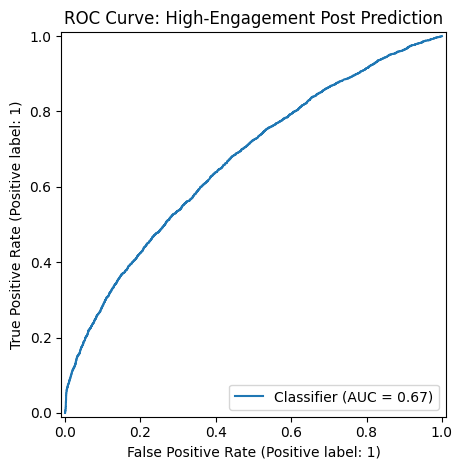

In [82]:
if "engagement_probabilities" in globals():
    RocCurveDisplay.from_predictions(
        test_engagement[
            "high_engagement"
        ],
        engagement_probabilities
    )

    plt.title(
        "ROC Curve: High-Engagement "
        "Post Prediction"
    )
    plt.tight_layout()
    plt.show()

### Interpreting the Engagement Model

Logistic regression coefficients identify words and phrases associated with the predicted high- and low-engagement classes. These features should be interpreted as statistical associations rather than causal effects.


In [83]:
if "engagement_model" in globals():
    feature_names = (
        engagement_model.named_steps[
            "tfidf"
        ].get_feature_names_out()
    )

    coefficients = (
        engagement_model.named_steps[
            "classifier"
        ].coef_[0]
    )

    coefficient_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    positive_engagement_features = (
        coefficient_df.nlargest(
            25,
            "coefficient"
        )
    )

    negative_engagement_features = (
        coefficient_df.nsmallest(
            25,
            "coefficient"
        )
    )

    print(
        "Features associated with "
        "high engagement"
    )
    display(
        positive_engagement_features
    )

    print(
        "Features associated with "
        "lower engagement"
    )
    display(
        negative_engagement_features
    )

Features associated with high engagement


,feature,coefficient
15811,edit,8.558336
31251,monday,3.501244
2391,adopted,3.483611
52224,ticker_uwmc,3.467550
55449,uwmc,3.198259
11429,cnbc,2.895524
30678,megathread,2.618577
10810,ceo,2.605371
6819,awards,2.578738
1487,50k,2.538747


Features associated with lower engagement


,feature,coefficient
14836,doge,-4.029238
41254,robinhood,-3.713414
32405,nakd,-3.578993
14843,dogecoin,-3.413184
9560,buy,-3.280932
51943,thoughts,-3.224425
55022,url,-3.009558
3814,and,-2.893141
8571,blocked,-2.870038
25720,is,-2.867738


## 14. Relationship between Discussion Signals and Future Activity

A final extension can investigate whether Reddit discussion signals precede future community activity.

This example predicts whether a ticker’s number of mentions will increase on the following day. It uses lagged discussion volume, sentiment, and engagement rather than individual post text.

This remains a Reddit-activity prediction problem. To investigate market outcomes, the aggregated data would need to be joined with external price and trading-volume data using carefully aligned market dates.


In [84]:
if "post_date" in analysis_df.columns:
    ticker_daily_features = (
        analysis_df[
            [
                "post_date",
                "tickers",
                "vader_compound",
                "engagement_score"
            ]
        ]
        .explode("tickers")
        .dropna(subset=["tickers"])
        .groupby(
            ["post_date", "tickers"]
        )
        .agg(
            mentions=(
                "tickers",
                "size"
            ),
            average_sentiment=(
                "vader_compound",
                "mean"
            ),
            total_engagement=(
                "engagement_score",
                "sum"
            )
        )
        .reset_index()
        .sort_values(
            ["tickers", "post_date"]
        )
    )

    display(
        ticker_daily_features.head()
    )

,post_date,tickers,mentions,average_sentiment,total_engagement
5585,2021-06-25 00:00:00+00:00,AA,1,0.995200,5.700444
4,2021-01-28 00:00:00+00:00,AAL,1,-0.493900,0.693147
56,2021-01-29 00:00:00+00:00,AAL,24,0.134908,97.223270
213,2021-01-30 00:00:00+00:00,AAL,1,0.907000,8.778018
317,2021-02-01 00:00:00+00:00,AAL,1,-0.990800,10.398336


In [85]:
if "ticker_daily_features" in globals():
    grouped_tickers = (
        ticker_daily_features.groupby(
            "tickers"
        )
    )

    ticker_daily_features[
        "mentions_lag_1"
    ] = grouped_tickers[
        "mentions"
    ].shift(1)

    ticker_daily_features[
        "mentions_rolling_7"
    ] = grouped_tickers[
        "mentions"
    ].transform(
        lambda values: (
            values.shift(1)
            .rolling(
                7,
                min_periods=3
            )
            .mean()
        )
    )

    ticker_daily_features[
        "sentiment_lag_1"
    ] = grouped_tickers[
        "average_sentiment"
    ].shift(1)

    ticker_daily_features[
        "engagement_lag_1"
    ] = grouped_tickers[
        "total_engagement"
    ].shift(1)

    ticker_daily_features[
        "next_day_mentions"
    ] = grouped_tickers[
        "mentions"
    ].shift(-1)

    ticker_daily_features[
        "mentions_increase_next_day"
    ] = (
        ticker_daily_features[
            "next_day_mentions"
        ]
        >
        ticker_daily_features[
            "mentions"
        ]
    ).astype(int)

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score

In [87]:
if "ticker_daily_features" in globals():
    activity_model_df = (
        ticker_daily_features.dropna(
            subset=[
                "mentions_lag_1",
                "mentions_rolling_7",
                "sentiment_lag_1",
                "engagement_lag_1",
                "next_day_mentions"
            ]
        )
        .sort_values("post_date")
        .copy()
    )

    feature_columns = [
        "tickers",
        "mentions",
        "mentions_lag_1",
        "mentions_rolling_7",
        "average_sentiment",
        "sentiment_lag_1",
        "total_engagement",
        "engagement_lag_1"
    ]

    target_column = (
        "mentions_increase_next_day"
    )

    split_position = int(
        len(activity_model_df) * 0.80
    )

    train_activity = (
        activity_model_df.iloc[
            :split_position
        ]
    )

    test_activity = (
        activity_model_df.iloc[
            split_position:
        ]
    )

In [88]:
if "activity_model_df" in globals() and len(activity_model_df) > 0:
    categorical_features = [
        "tickers"
    ]

    numeric_features = [
        column
        for column in feature_columns
        if column not in categorical_features
    ]

    numeric_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ])

    categorical_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessing = ColumnTransformer([
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ])

    activity_model = Pipeline([
        (
            "preprocessing",
            preprocessing
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])

    activity_model.fit(
        train_activity[
            feature_columns
        ],
        train_activity[
            target_column
        ]
    )

    activity_predictions = (
        activity_model.predict(
            test_activity[
                feature_columns
            ]
        )
    )

    print(
        classification_report(
            test_activity[
                target_column
            ],
            activity_predictions,
            digits=3
        )
    )

    print(
        "Balanced accuracy:",
        balanced_accuracy_score(
            test_activity[
                target_column
            ],
            activity_predictions
        )
    )

              precision    recall  f1-score   support

           0      0.820     0.573     0.675       628
           1      0.297     0.589     0.394       192

    accuracy                          0.577       820
   macro avg      0.558     0.581     0.535       820
weighted avg      0.697     0.577     0.609       820

Balanced accuracy: 0.5808950371549894


## 15. Conclusions and Limitations

This extended analysis moves beyond descriptive word frequencies and examines several complementary aspects of WallStreetBets language.

Ticker extraction identifies which securities dominate the discussion and how their popularity changes over time. VADER and FinBERT provide alternative estimates of sentiment, while stance detection distinguishes general emotional polarity from explicit bullish or bearish investment positions. Flair classification examines the communicative purpose of each post, and BERTopic identifies recurring narratives without requiring predefined labels.

The emerging-narrative section highlights unusual changes in ticker attention. Semantic search supports qualitative exploration of similar investment claims, while near-duplicate detection identifies repeated or copied narratives. Emotion classification adds more specific affective categories, and the predictive sections test whether language and discussion signals are associated with engagement or subsequent Reddit activity.

Several limitations should be considered:

1. The corpus represents posts available in the dataset and may not include deleted or removed content.
2. Ticker extraction remains vulnerable to ambiguous uppercase words and incomplete symbol dictionaries.
3. Sentiment, stance, emotion, and topic labels are model estimates rather than objective facts.
4. Reddit score and comment counts can change after data collection.
5. Engagement models identify correlation rather than causation.
6. Financial prediction requires careful alignment with market prices, trading calendars, splits, and after-hours posting.
7. Evaluation based on random splits may overestimate performance when duplicated or time-related content is present.
8. WallStreetBets language evolves, so models and slang dictionaries may become outdated.
9. Results derived from this community should not be generalised to all retail investors.
10. None of the analyses should be interpreted as financial advice.

The most valuable future extension would be to join daily ticker-level Reddit indicators with adjusted market prices and trading volume. This would enable event studies, lead-lag analysis, volatility modelling, and a comparison between discussion volume, sentiment, and investment stance as potential explanatory signals.
